# Modelado — Predicción de Gravedad de Accidentes de Tránsito en Colombia

Este notebook contiene el dataset limpio con feature engineering y todos los modelos de clasificación binaria:
- **Target:** CON HERIDOS (0) vs CON MUERTOS (1) — desbalanceo 95/5
- **Features:** TIPO_VEHICULO, MODELO_ESPECIFICO, EDAD_VEHICULO, CAT_EDAD_VEHICULO, DEPARTAMENTO_ACCIDENTE, ES_VACACIONES, DIA_SEMANA

---

## 1. Carga y Limpieza del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
%matplotlib inline

In [2]:
df = pd.read_csv(
    'VEHICULOS_INVOLUCRADOS_EN_UN_ACCIDENTE_DE_TRANSITO_LEY_2251-2022_20260205.csv',
    encoding='latin-1'
)
print(f"Dimensiones del dataset: {df.shape[0]:,} registros × {df.shape[1]} variables")
df.head()

Dimensiones del dataset: 406,540 registros × 9 variables


,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
0,HONDA,2017,MOTOCICLETA,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
1,CHEVROLET,2007,CAMION,20.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
2,JEEP,2017,CAMPERO,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
3,CHEVROLET,2023,CAMIONETA,2.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
4,HONDA,2026,MOTOCICLETA,1.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA


In [4]:
# Corrección de tipos de datos
df['EDAD_VEHICULO']   = pd.to_numeric(df['EDAD_VEHICULO'],   errors='coerce')
df['MODELO_VEHICULO'] = pd.to_numeric(df['MODELO_VEHICULO'], errors='coerce')
df['FECHA_ACCIDENTE'] = pd.to_datetime('01/' + df['FECHA_ACCIDENTE'], format='%d/%m/%Y')

print("Tipos de datos corregidos:")
print(df[['EDAD_VEHICULO','MODELO_VEHICULO','FECHA_ACCIDENTE']].dtypes)

Tipos de datos corregidos:
EDAD_VEHICULO             float64
MODELO_VEHICULO             int64
FECHA_ACCIDENTE    datetime64[ns]
dtype: object


In [10]:
# MARCA_VEHICULO: nulos estructurales → "Sin información"
df['MARCA_VEHICULO'] = df['MARCA_VEHICULO'].fillna("Sin información")

# EDAD_VEHICULO: imputar con mediana por TIPO_VEHICULO
# Justificación: diferentes tipos de vehículo tienen distribuciones de edad muy distintas.
# Una mediana global introduciría sesgo (ej. la edad típica de una moto ≠ la de un camión).
df['EDAD_VEHICULO'] = df.groupby('TIPO_VEHICULO')['EDAD_VEHICULO'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback global para tipos con todos los valores nulos
df['EDAD_VEHICULO'] = df['EDAD_VEHICULO'].fillna(df['EDAD_VEHICULO'].median())

print("Nulos después de imputación:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos después de imputación:
Series([], dtype: int64)


In [12]:
antes = len(df)

# Filtros de MODELO_VEHICULO
df = df[(df['MODELO_VEHICULO'] >= 1950) & (df['MODELO_VEHICULO'] <= 2025)]
print(f"Eliminados por MODELO_VEHICULO fuera de [1950, 2025]: {antes - len(df):,}")

# Cap de EDAD_VEHICULO
antes2 = len(df)
df = df[df['EDAD_VEHICULO'] <= 60]
print(f"Eliminados por EDAD_VEHICULO > 60 años: {antes2 - len(df):,}")
print(f"Registros restantes: {len(df):,}")

Eliminados por MODELO_VEHICULO fuera de [1950, 2025]: 2,964
Eliminados por EDAD_VEHICULO > 60 años: 449
Registros restantes: 403,127


In [13]:
# Extraer componentes temporales (necesarios para los filtros)
df['AÑO']      = df['FECHA_ACCIDENTE'].dt.year
df['MES']      = df['FECHA_ACCIDENTE'].dt.month
df['MES_NOMBRE'] = df['FECHA_ACCIDENTE'].dt.month_name()
df['TRIMESTRE']  = df['FECHA_ACCIDENTE'].dt.quarter
df['SEMESTRE']   = df['FECHA_ACCIDENTE'].apply(lambda x: 1 if x.month <= 6 else 2)
df['DIA_SEMANA'] = df['FECHA_ACCIDENTE'].dt.day_name()  # Para análisis semanal (Objetivo 3)

print("Componentes temporales extraídos correctamente.")
print(df[['FECHA_ACCIDENTE','AÑO','MES','DIA_SEMANA']].head(3))

Componentes temporales extraídos correctamente.
  FECHA_ACCIDENTE   AÑO  MES DIA_SEMANA
0      2025-12-01  2025   12     Monday
1      2025-12-01  2025   12     Monday
2      2025-12-01  2025   12     Monday


In [14]:
# ── Filtro 1: Excluir 2026 (año incompleto, distorsiona tasas de mortalidad) ──
df = df[df['AÑO'] <= 2025]
print(f"Registros tras excluir 2026: {len(df):,}")

# ── Filtro 2: Excluir anomalía julio 2024 ──
# El 78.7% de los 28,794 registros de julio 2024 provienen de un único reportante
# ('STRIA DE TTOyTTE MEDELLIN'), con una tasa de mortalidad que cayó de 4.24% a 1.38%
# mientras el volumen se triplicaba — relación inversa incompatible con un fenómeno real.
# Conclusión: error de carga masiva de registros.
mascara_anomalia = ~(
    (df['AÑO'] == 2024) &
    (df['MES'] == 7) &
    (df['AUTORIDAD_DE_TRANSITO'] == 'STRIA DE TTOyTTE MEDELLIN')
)
antes = len(df)
df = df[mascara_anomalia]
print(f"Eliminados por anomalía julio 2024: {antes - len(df):,}")
print(f"Dataset final para análisis: {len(df):,} registros")

Registros tras excluir 2026: 401,137
Eliminados por anomalía julio 2024: 22,667
Dataset final para análisis: 378,470 registros


In [15]:
# ── Objetivo 1: MODELO_ESPECIFICO (marca + año de fabricación) ──
# La marca sola tiene baja asociación con la gravedad (V de Cramér débil).
# Al combinarla con el año se captura la variación dentro de cada marca.
df['MODELO_ESPECIFICO'] = df['MARCA_VEHICULO'].astype(str) + ' ' + df['MODELO_VEHICULO'].astype(str)

# ── Objetivo 2: ANTIGÜEDAD_VEHICULO y su categorización ──
# ANTIGÜEDAD es el cálculo preciso desde el año del accidente,
# mientras que EDAD_VEHICULO es la variable original (con errores ya filtrados).
df['ANTIGÜEDAD_VEHICULO'] = df['FECHA_ACCIDENTE'].dt.year - df['MODELO_VEHICULO']

bins_edad   = [0, 5, 10, 20, float('inf')]
labels_edad = ['0-5 años', '6-10 años', '11-20 años', '>20 años']
df['CAT_EDAD_VEHICULO'] = pd.cut(df['ANTIGÜEDAD_VEHICULO'], bins=bins_edad, labels=labels_edad)

# ── Objetivo 3: Variables temporales adicionales ──
meses_vacaciones  = [1, 6, 7, 12]
meses_alto_riesgo = [7, 9, 3, 5]   # Basado en estacionalidad observada
df['ES_VACACIONES']     = df['MES'].isin(meses_vacaciones).astype(int)
df['ES_MES_ALTO_RIESGO'] = df['MES'].isin(meses_alto_riesgo).astype(int)

print("Variables derivadas creadas:")
print(f"  MODELO_ESPECIFICO   → {df['MODELO_ESPECIFICO'].nunique():,} combinaciones únicas")
print(f"  ANTIGÜEDAD_VEHICULO → media = {df['ANTIGÜEDAD_VEHICULO'].mean():.1f} años")
print(f"  CAT_EDAD_VEHICULO   → {df['CAT_EDAD_VEHICULO'].value_counts().to_dict()}")
print(f"  ES_VACACIONES       → {df['ES_VACACIONES'].sum():,} registros en períodos vacacionales")

Variables derivadas creadas:
  MODELO_ESPECIFICO   → 2,977 combinaciones únicas
  ANTIGÜEDAD_VEHICULO → media = 7.5 años
  CAT_EDAD_VEHICULO   → {'0-5 años': 128889, '6-10 años': 98880, '11-20 años': 82077, '>20 años': 18627}
  ES_VACACIONES       → 120,672 registros en períodos vacacionales


In [63]:
INCLUIR = [
    'TIPO_VEHICULO',
    'MODELO_ESPECIFICO',
    'EDAD_VEHICULO',
    'CAT_EDAD_VEHICULO',
    'DEPARTAMENTO_ACCIDENTE',
    'ES_VACACIONES',
    'DIA_SEMANA'
]

EXCLUIR = [
    'MODELO_VEHICULO',
    'MES',
    'TRIMESTRE',
    'SEMESTRE',
    'AUTORIDAD_DE_TRANSITO',
    'MUNICIPIO_ACCIDENTE'
]

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 378470 entries, 0 to 406539
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   MARCA_VEHICULO          378470 non-null  object        
 1   MODELO_VEHICULO         378470 non-null  int64         
 2   TIPO_VEHICULO           378470 non-null  object        
 3   EDAD_VEHICULO           378470 non-null  float64       
 4   FECHA_ACCIDENTE         378470 non-null  datetime64[ns]
 5   GRAVEDAD_ACCIDENTE      378470 non-null  object        
 6   DEPARTAMENTO_ACCIDENTE  378470 non-null  object        
 7   MUNICIPIO_ACCIDENTE     378470 non-null  object        
 8   AUTORIDAD_DE_TRANSITO   378470 non-null  object        
 9   AÑO                     378470 non-null  int32         
 10  MES                     378470 non-null  int32         
 11  MES_NOMBRE              378470 non-null  object        
 12  TRIMESTRE               378470 non-

---
## 2. Preprocesamiento y Split Train/Test

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import make_scorer  
import time
import joblib

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve, auc, precision_score, recall_score,
    ConfusionMatrixDisplay, make_scorer
)


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name,
                   cv_folds=5, make_plots=True, refit=True):  # ← parámetro agregado
    """
    Evalúa un modelo con F1-Macro como métrica principal.
    Incluye validación cruzada + evaluación en test set + gráficas.

    Parámetros
    ----------
    refit : bool
        Si True, re-entrena el modelo con X_train antes de evaluar en test.
        Pasar refit=False cuando el modelo ya fue entrenado (ej: best_estimator_
        de GridSearchCV) para evitar entrenamiento redundante.
    """
    results_cv = {}

    # ── VALIDACIÓN CRUZADA ────────────────────────────────────────────────────
    if cv_folds > 0:
        print(f"\n{'='*60}")
        print(f"VALIDACIÓN CRUZADA ({cv_folds} folds) - {model_name}")
        print(f"{'='*60}")

        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

        scoring = {
            'accuracy':        'accuracy',
            'precision_macro': 'precision_macro',
            'recall_macro':    'recall_macro',
            'f1_macro':        'f1_macro',
            'f1_weighted':     'f1_weighted',
        }

        if hasattr(model, "predict_proba"):
            scoring['roc_auc'] = make_scorer(
                roc_auc_score, needs_proba=True,
                multi_class='ovr', average='weighted'
            )

        cv_results = cross_validate(
            model, X_train, y_train,
            cv=cv, scoring=scoring,
            n_jobs=-1, return_train_score=True
        )

        results_cv = {
            'cv_accuracy_mean':       cv_results['test_accuracy'].mean(),
            'cv_accuracy_std':        cv_results['test_accuracy'].std(),
            'cv_f1_macro_mean':       cv_results['test_f1_macro'].mean(),
            'cv_f1_macro_std':        cv_results['test_f1_macro'].std(),
            'cv_f1_weighted_mean':    cv_results['test_f1_weighted'].mean(),
            'cv_f1_weighted_std':     cv_results['test_f1_weighted'].std(),
            'cv_train_f1_macro_mean': cv_results['train_f1_macro'].mean(),
            'cv_train_accuracy_mean': cv_results['train_accuracy'].mean(),
        }

        if 'test_roc_auc' in cv_results:
            results_cv['cv_auc_mean'] = cv_results['test_roc_auc'].mean()
            results_cv['cv_auc_std']  = cv_results['test_roc_auc'].std()

        print(f"   F1-Macro (CV):    {results_cv['cv_f1_macro_mean']:.4f} ± {results_cv['cv_f1_macro_std']:.4f}  ← PRINCIPAL")
        print(f"   Accuracy (CV):    {results_cv['cv_accuracy_mean']:.4f} ± {results_cv['cv_accuracy_std']:.4f}")
        print(f"   F1-Weighted (CV): {results_cv['cv_f1_weighted_mean']:.4f} ± {results_cv['cv_f1_weighted_std']:.4f}")
        if 'cv_auc_mean' in results_cv:
            print(f"   AUC (CV):         {results_cv['cv_auc_mean']:.4f} ± {results_cv['cv_auc_std']:.4f}")

        gap = results_cv['cv_train_f1_macro_mean'] - results_cv['cv_f1_macro_mean']
        print(f"\n   Gap Train-Val F1-Macro: {gap:.4f}", end=" ")
        print("Posible overfitting" if gap > 0.05 else "Sin overfitting aparente")

    # ── EVALUACIÓN EN TEST SET ────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"EVALUACIÓN EN TEST SET - {model_name}")
    print(f"{'='*60}")

    start_time = time.time()
    if refit:                          # ← solo entrena si refit=True
        model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    accuracy        = accuracy_score(y_test, y_pred)
    f1_macro        = f1_score(y_test, y_pred, average='macro',    zero_division=0)
    f1_weighted     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_test, y_pred,    average='macro', zero_division=0)

    auc_score = None
    if y_pred_proba is not None and len(np.unique(y_test)) > 1:
        try:
            if len(np.unique(y_test)) == 2:
                auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
            else:
                auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        except Exception as e:
            print(f"Warning AUC ({model_name}): {e}")

    print(f"   F1-Macro:        {f1_macro:.4f}  ← PRINCIPAL")
    print(f"   Accuracy:        {accuracy:.4f}")
    print(f"   F1-Weighted:     {f1_weighted:.4f}")
    print(f"   Precision-Macro: {precision_macro:.4f}")
    print(f"   Recall-Macro:    {recall_macro:.4f}")
    if auc_score:
        print(f"   AUC:             {auc_score:.4f}")
    print(f"   Tiempo entreno:  {train_time:.2f}s")

    print("\n   Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=['CON HERIDOS', 'CON MUERTOS']))

    # ── GRÁFICAS ──────────────────────────────────────────────────────────────
    if make_plots:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f"Evaluación: {model_name}", fontsize=13, fontweight='bold')

        if y_pred_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
            roc_auc_val = auc(fpr, tpr)
            ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
            ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Línea base')
            ax1.set_xlabel('Tasa de Falsos Positivos')
            ax1.set_ylabel('Tasa de Verdaderos Positivos')
            ax1.set_title('Curva ROC')
            ax1.legend()
            ax1.grid(alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No disponible', ha='center', va='center', transform=ax1.transAxes)

        ConfusionMatrixDisplay.from_estimator(
            model, X_test, y_test,
            display_labels=['CON HERIDOS', 'CON MUERTOS'],  # ← corregido también
            cmap='Blues', ax=ax2
        )
        ax2.set_title('Matriz de Confusión')
        plt.tight_layout()
        plt.show()

    # ── RESULTADO ─────────────────────────────────────────────────────────────
    result = {
        'model':           model_name,
        'accuracy':        accuracy,
        'f1_macro':        f1_macro,
        'f1_weighted':     f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro':    recall_macro,
        'auc':             auc_score,
        'train_time':      train_time,
        'predictions':     y_pred,
        'probabilities':   y_pred_proba,
        'f1':              f1_macro,
        'precision':       precision_macro,
        'recall':          recall_macro,
    }

    if results_cv:
        result.update(results_cv)

    return result

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    accuracy_score, f1_score, roc_curve, auc, precision_score, recall_score,
    ConfusionMatrixDisplay, balanced_accuracy_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lime
import lime.lime_tabular
from sklearn.metrics import make_scorer

In [ ]:
# 1. Definir características (Tus nuevas variables)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
numeric_features = ['EDAD_VEHICULO']

categorical_features = [
    'TIPO_VEHICULO', 'DEPARTAMENTO_ACCIDENTE', 'DIA_SEMANA', 
    'ES_VACACIONES', 'CAT_EDAD_VEHICULO', 'MODELO_ESPECIFICO'
]


results = []
# 2. Variable objetivo
# Asumiendo que tu DataFrame original se llama 'df'
dataset_clean = df.copy()

# ---> ¡IMPORTANTE! Ajusta 'TU_VARIABLE_OBJETIVO' al nombre real de tu columna (ej: 'MORTALIDAD' o 'GRAVEDAD')
# Si tu variable ya es 0 y 1, solo asígnala. Si necesitas una condición (ej. Gravedad >= X), hazlo así:
dataset_clean['Target'] = dataset_clean['GRAVEDAD_ACCIDENTE'].apply(lambda x: 1 if x == 'CON MUERTOS' else 0)

X = dataset_clean[numeric_features + categorical_features]
y = dataset_clean['Target']

# 3. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Nombres de las clases para los gráficos (ajústalos según tu caso)
class_names = ['CON HERIDOS', 'CON MUERTOS']

print(f"Distribución de clases en entrenamiento:")
print(f"   Clase 0 ({class_names[0]}): {sum(y_train == 0)} muestras ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"   Clase 1 ({class_names[1]}):    {sum(y_train == 1)} muestras ({sum(y_train == 1)/len(y_train)*100:.1f}%)")

# 4. Preprocesadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Distribución de clases en entrenamiento:
   Clase 0 (CON HERIDOS): 286666 muestras (94.7%)
   Clase 1 (CON MUERTOS):    16110 muestras (5.3%)


---
## 3. Modelos de Clasificación

Todos los modelos usan el mismo `preprocessor` y `X_train/X_test/y_train/y_test` definidos arriba.

Distribución — HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79

Búsqueda de hiperparámetros con RandomizedSearchCV
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros:    {'model__subsample': 0.9, 'model__scale_pos_weight': 8.897144630664183, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}
Mejor F1-MUERTOS (CV): 0.2522

Umbral óptimo encontrado: 0.5448 (default era 0.5)

── Comparación umbral default vs optimizado ──
Métrica                     Default (0.5)      Optimizado
-------------------------------------------------------
  F1-MUERTOS:  0.2443
  F1-Macro:    0.5848
  Recall:      0.4130
  Precision:   0.1735

  F1-MUERTOS:  0.2513
  F1-Macro:    0.5962
  Recall:      0.3444
  Precision:   0.1978


VALIDACIÓN CRUZADA (5 folds) - XGBoost (Optimized + Threshold)
   F1-Macro (CV):    0.5887 ± 0.0014  ← PRINCIPAL
   Accuracy (CV):    0.8641 ± 0.0021
   F1-Wei

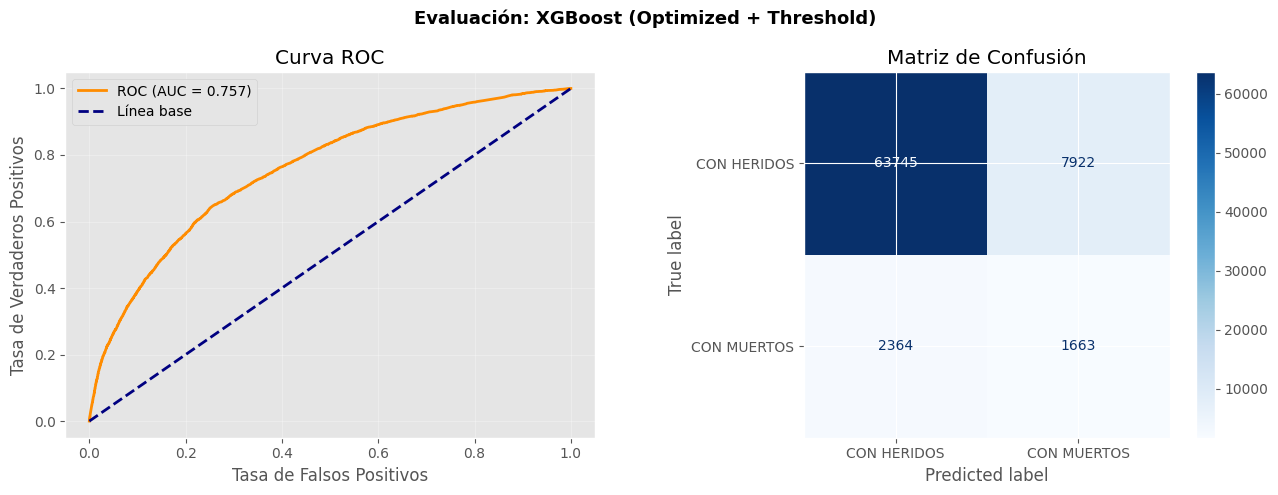


AUCPR (Precision-Recall): 0.1772
(Un clasificador aleatorio con 5% positivos tendría AUCPR ≈ 0.05)


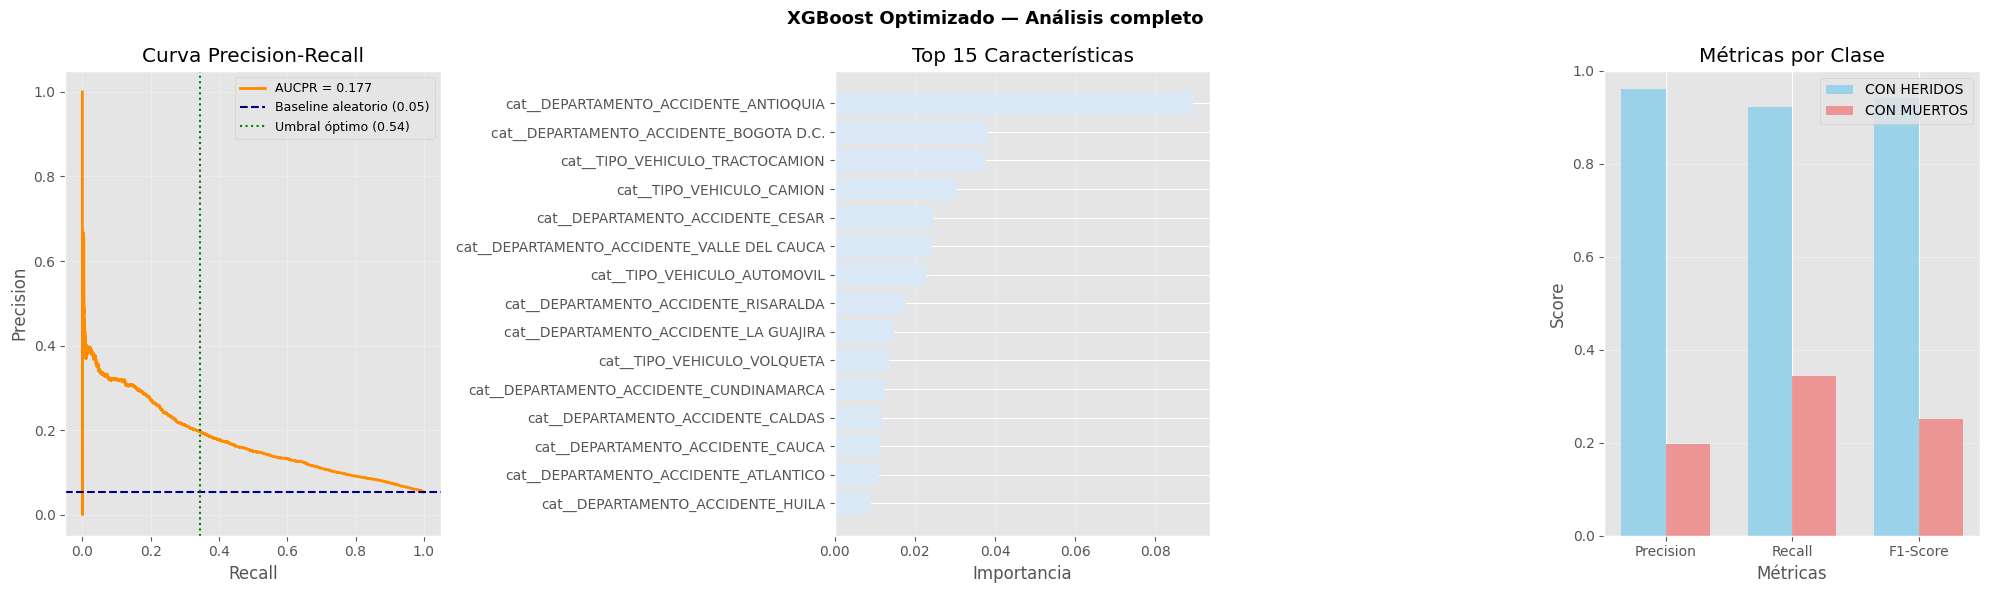


Top 10 características importantes:
                                        feature  importance
28        cat__DEPARTAMENTO_ACCIDENTE_ANTIOQUIA      0.0894
32      cat__DEPARTAMENTO_ACCIDENTE_BOGOTA D.C.      0.0382
25              cat__TIPO_VEHICULO_TRACTOCAMION      0.0377
4                     cat__TIPO_VEHICULO_CAMION      0.0305
39            cat__DEPARTAMENTO_ACCIDENTE_CESAR      0.0248
57  cat__DEPARTAMENTO_ACCIDENTE_VALLE DEL CAUCA      0.0243
1                  cat__TIPO_VEHICULO_AUTOMOVIL      0.0228
53        cat__DEPARTAMENTO_ACCIDENTE_RISARALDA      0.0177
46       cat__DEPARTAMENTO_ACCIDENTE_LA GUAJIRA      0.0149
27                  cat__TIPO_VEHICULO_VOLQUETA      0.0135

Interpretabilidad con LIME - XGBoost

1. CASO CON MUERTOS correctamente clasificado


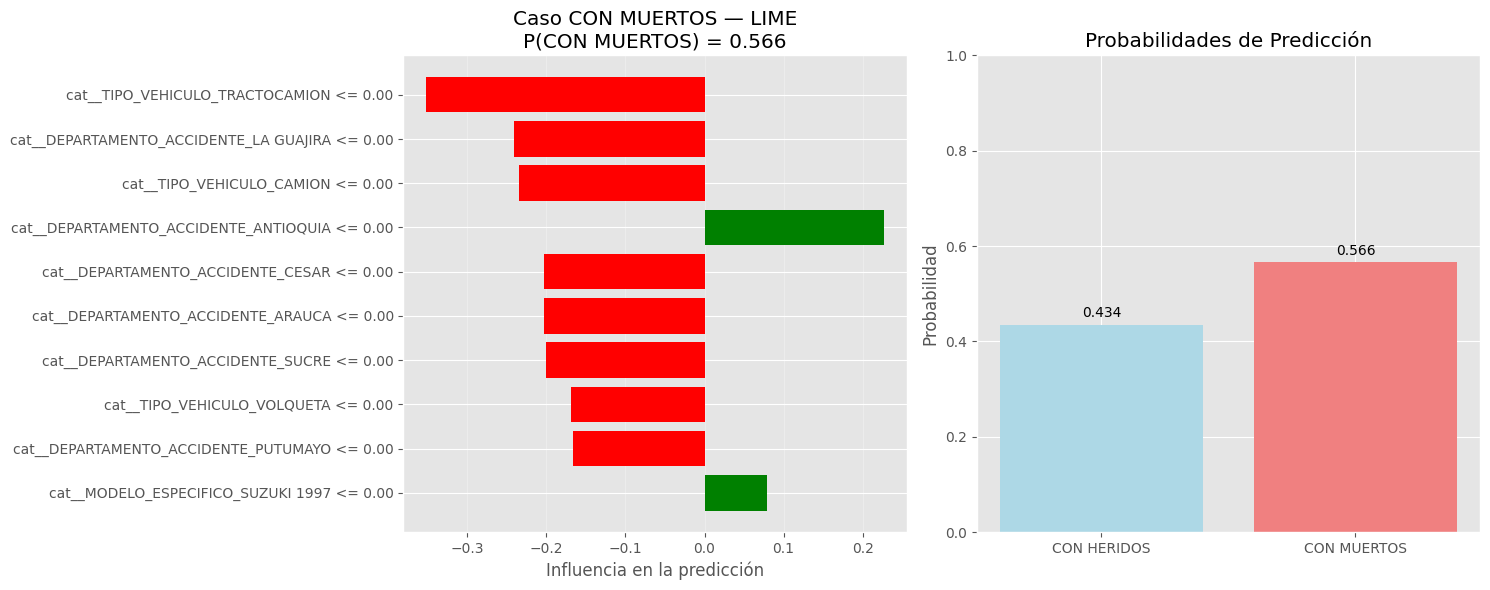


2. CASO CON HERIDOS correctamente clasificado


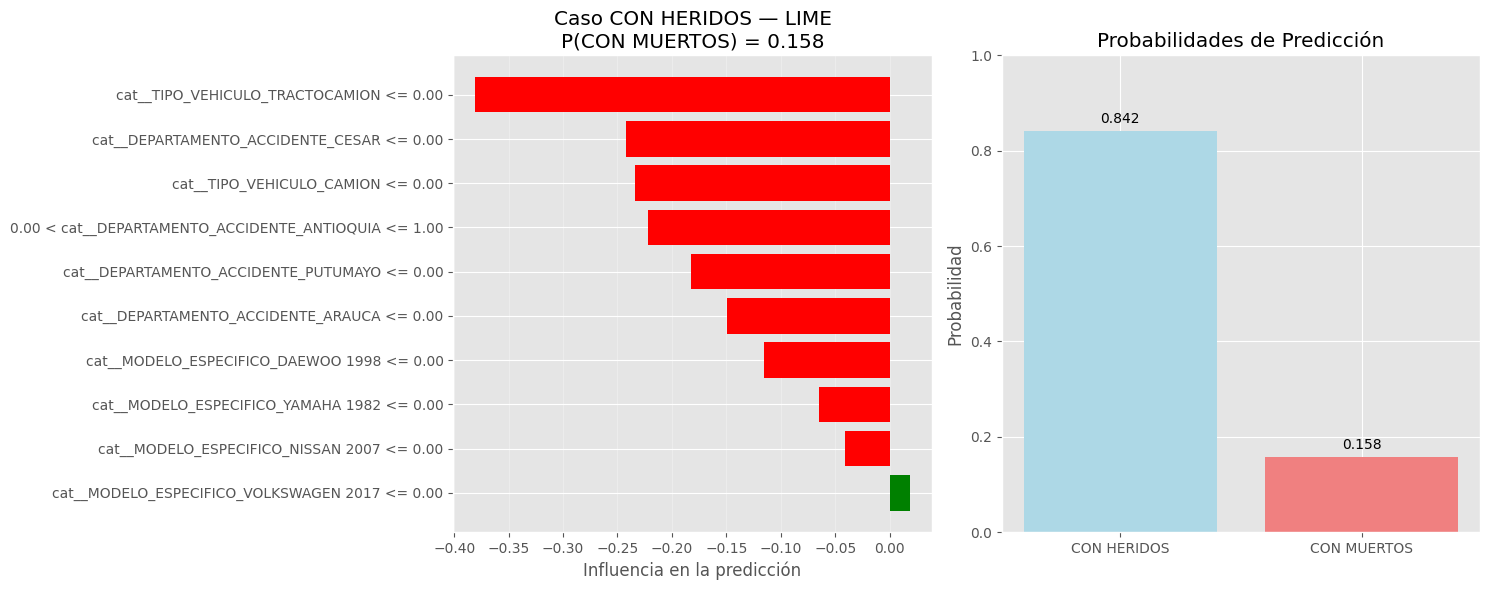

In [ ]:
import xgboost as xgb
import lime
import lime.lime_tabular
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, average_precision_score

# ── RATIO DE BALANCEO ─────────────────────────────────────────────────────────
neg = (y_train == 0).sum()  # CON HERIDOS
pos = (y_train == 1).sum()  # CON MUERTOS
ratio = neg / pos
print(f"Distribución — HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        random_state=42,
        eval_metric='aucpr',       # más honesto que logloss con desbalance
        scale_pos_weight=ratio,    # balanceo nativo GPU-compatible
        max_delta_step=1,          # estabiliza gradientes con desbalance severo
        device='cuda',
        tree_method='hist',
        nthread=-1
    ))
])

# ── PARAM GRID ────────────────────────────────────────────────────────────────
param_grid = {
    "model__n_estimators":     [200, 300, 400],
    "model__max_depth":        [3, 5],
    "model__learning_rate":    [0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__min_child_weight": [1, 5, 10],          # clave con desbalance
    "model__scale_pos_weight": [ratio * 0.5, ratio, ratio * 1.5]
}

# ── RANDOMIZED SEARCH ─────────────────────────────────────────────────────────
print("\nBúsqueda de hiperparámetros con RandomizedSearchCV")
grid_search = RandomizedSearchCV(
    pipe_xgb, param_grid,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=make_scorer(f1_score, pos_label=1),   # F1 de MUERTOS como estrella polar
    n_jobs=1,
    random_state=42,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros:    {grid_search.best_params_}")
print(f"Mejor F1-MUERTOS (CV): {grid_search.best_score_:.4f}")

final_model = grid_search.best_estimator_

# ── THRESHOLD TUNING ──────────────────────────────────────────────────────────
# Con desbalance severo el umbral 0.5 por defecto es subóptimo
from sklearn.metrics import precision_recall_curve

y_proba_val = final_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_val)
f1_scores_thresh = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_thresh = thresholds[np.argmax(f1_scores_thresh)]
print(f"\nUmbral óptimo encontrado: {best_thresh:.4f} (default era 0.5)")

# Predicciones con umbral ajustado
y_pred_opt   = (y_proba_val >= best_thresh).astype(int)
y_pred_default = final_model.predict(X_test)

print("\n── Comparación umbral default vs optimizado ──")
print(f"{'Métrica':<25} {'Default (0.5)':>15} {'Optimizado':>15}")
print("-" * 55)
for nombre, pred in [("Default (0.5)", y_pred_default), ("Optimizado", y_pred_opt)]:
    f1_min  = f1_score(y_test, pred, pos_label=1)
    f1_mac  = f1_score(y_test, pred, average='macro')
    rec_min = recall_score(y_test, pred, pos_label=1)
    pre_min = precision_score(y_test, pred, pos_label=1)
    print(f"  F1-MUERTOS:  {f1_min:.4f}")
    print(f"  F1-Macro:    {f1_mac:.4f}")
    print(f"  Recall:      {rec_min:.4f}")
    print(f"  Precision:   {pre_min:.4f}")
    print()

# Usar predicciones con umbral optimizado para el resto
y_pred = y_pred_opt

# ── EVALUACIÓN ────────────────────────────────────────────────────────────────
result = evaluate_model(
    final_model,
    X_train, X_test, y_train, y_test,
    model_name="XGBoost (Optimized + Threshold)",
    cv_folds=5,
    make_plots=True,
    refit=False
)
results.append(result)

# ── MÉTRICAS COMPLETAS ────────────────────────────────────────────────────────
y_pred_proba     = result['probabilities']
y_pred_proba_pos = y_pred_proba[:, 1] if y_pred_proba is not None else None

aucpr = average_precision_score(y_test, y_pred_proba_pos)
print(f"\nAUCPR (Precision-Recall): {aucpr:.4f}")
print(f"(Un clasificador aleatorio con 5% positivos tendría AUCPR ≈ 0.05)")

precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test, y_pred,    pos_label=0, zero_division=0)
recall_1    = recall_score(y_test, y_pred,    pos_label=1, zero_division=0)
f1_0        = f1_score(y_test, y_pred,        pos_label=0, zero_division=0)
f1_1        = f1_score(y_test, y_pred,        pos_label=1, zero_division=0)

# ── GRÁFICAS ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("XGBoost Optimizado — Análisis completo", fontsize=13, fontweight='bold')

# Curva Precision-Recall
axes[0].plot(recalls, precisions, color='darkorange', lw=2,
             label=f'AUCPR = {aucpr:.3f}')
axes[0].axhline(y=pos/(neg+pos), color='navy', linestyle='--',
                label=f'Baseline aleatorio ({pos/(neg+pos):.2f})')
axes[0].axvline(x=recalls[np.argmax(f1_scores_thresh)], color='green',
                linestyle=':', label=f'Umbral óptimo ({best_thresh:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Importancia de características
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importances   = final_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top_features = importance_df.head(15)
axes[1].barh(top_features['feature'], top_features['importance'])
axes[1].set_xlabel('Importancia')
axes[1].set_title('Top 15 Características')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

# Métricas por clase
x     = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, [precision_0, recall_0, f1_0], width,
            label=class_names[0], alpha=0.8, color='skyblue')
axes[2].bar(x + width/2, [precision_1, recall_1, f1_1], width,
            label=class_names[1], alpha=0.8, color='lightcoral')
axes[2].set_xlabel('Métricas')
axes[2].set_ylabel('Score')
axes[2].set_title('Métricas por Clase')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Precision', 'Recall', 'F1-Score'])
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── LIME ──────────────────────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - XGBoost")

X_train_processed = final_model.named_steps['preprocessor'].transform(X_train)
X_test_processed  = final_model.named_steps['preprocessor'].transform(X_test)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)


def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]

    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()

    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad')
    ax2.set_title('Probabilidades de Predicción')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


if y_pred_proba_pos is not None:
    # Caso CON MUERTOS correctamente clasificado
    idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
    if len(idx_1) > 0:
        i = idx_1[0]
        print(f"\n1. CASO {class_names[1]} correctamente clasificado")
        exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
        plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_pred_proba_pos[i])

    # Caso CON HERIDOS correctamente clasificado
    idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
    if len(idx_0) > 0:
        i = idx_0[0]
        print(f"\n2. CASO {class_names[0]} correctamente clasificado")
        exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
        plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_pred_proba_pos[i])
        

joblib.dump(final_model, 'xgboost_optimized_model.joblib')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros: {'model__C': 0.01, 'model__penalty': 'l1'}
Mejor F1-Macro (CV Grid): nan

VALIDACIÓN CRUZADA (5 folds) - Logistic Regression (Optimized)
   F1-Macro (CV):    0.5230 ± 0.0017  ← PRINCIPAL
   Accuracy (CV):    0.7338 ± 0.0026
   F1-Weighted (CV): 0.8064 ± 0.0018
   AUC (CV):         0.7554 ± 0.0027

   Gap Train-Val F1-Macro: 0.0001 Sin overfitting aparente

EVALUACIÓN EN TEST SET - Logistic Regression (Optimized)
   F1-Macro:        0.5244  ← PRINCIPAL
   Accuracy:        0.7367
   F1-Weighted:     0.8083
   Precision-Macro: 0.5484
   Recall-Macro:    0.6931
   AUC:             0.7545
   Tiempo entreno:  12.88s

   Reporte de clasificación:
              precision    recall  f1-score   support

 CON HERIDOS       0.97      0.74      0.84     71667
 CON MUERTOS       0.12      0.64      0.21      4027

    accuracy                           0.74     75694
   macro avg       0.55      0.69      0.52     75694

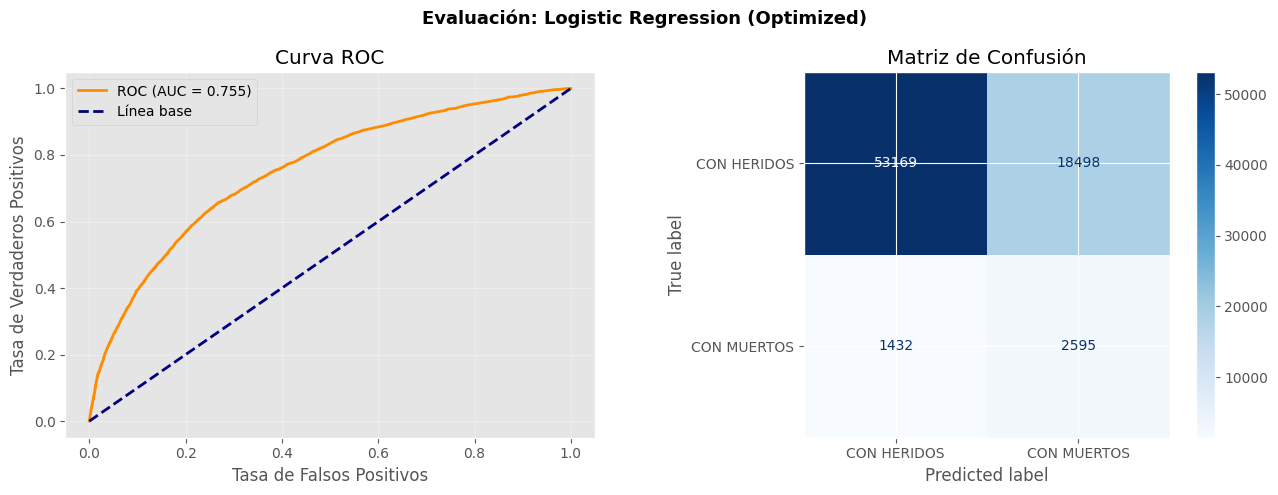


RESUMEN FINAL
                          Model  F1-Macro  Accuracy  F1-Weighted  Precision  Recall    AUC  Time(s)  CV_F1-Macro
            XGBoost (Optimized)    0.4868    0.9468       0.9210     0.8067  0.5002 0.7536  25.1068       0.4873
Logistic Regression (Optimized)    0.5244    0.7367       0.8083     0.5484  0.6931 0.7545  12.8783       0.5230


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='liblinear'
    ))
])

# ── GRID SEARCH ───────────────────────────────────────────────────────────────
param_grid = {
    "model__C":       [0.01, 0.1, 1, 10],
    "model__penalty": ['l1', 'l2']
}

grid_search = GridSearchCV(
    pipe_logreg, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1-Macro (CV Grid): {grid_search.best_score_:.4f}")

# ── EVALUACIÓN ────────────────────────────────────────────────────────────────
result = evaluate_model(
    grid_search.best_estimator_,
    X_train, X_test, y_train, y_test,
    model_name="Logistic Regression (Optimized)",
    cv_folds=5,
    make_plots=True,
    refit=True  # ← No re-entrenar, ya está optimizado y entrenado por GridSearchCV
)
results.append(result)

# ── TABLA FINAL ───────────────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':        r['model'],
    'F1-Macro':     r['f1_macro'],
    'Accuracy':     r['accuracy'],
    'F1-Weighted':  r['f1_weighted'],
    'Precision':    r['precision_macro'],
    'Recall':       r['recall_macro'],
    'AUC':          r['auc'],
    'Time(s)':      r['train_time'],
    'CV_F1-Macro':  r.get('cv_f1_macro_mean', None),
} for r in results])

print("\nRESUMEN FINAL")
print(results_df.round(4).to_string(index=False))

   X_train: (302776, 7), X_test: (75694, 7)
   y_train - Clase 0 (CON HERIDOS): 286666, Clase 1 (CON MUERTOS): 16110
   y_test  - Clase 0 (CON HERIDOS): 71667, Clase 1 (CON MUERTOS): 4027

Búsqueda de hiperparámetros con GridSearchCV
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros:  {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Mejor F1-Macro (CV): nan

VALIDACIÓN CRUZADA (5 folds) - Random Forest (Optimized)
   F1-Macro (CV):    0.5245 ± 0.0021  ← PRINCIPAL
   Accuracy (CV):    0.8989 ± 0.0009
   F1-Weighted (CV): 0.9016 ± 0.0006
   AUC (CV):         0.6471 ± 0.0056

   Gap Train-Val F1-Macro: 0.2833 Posible overfitting

EVALUACIÓN EN TEST SET - Random Forest (Optimized)
   F1-Macro:        0.5281  ← PRINCIPAL
   Accuracy:        0.8963
   F1-Weighted:     0.9006
   Precision-Macro: 0.5262
   Recall-Macro:    0.5309
   AUC:             0.6369
   Tiempo entreno:  154.12s

   Reporte de clasificación:
              

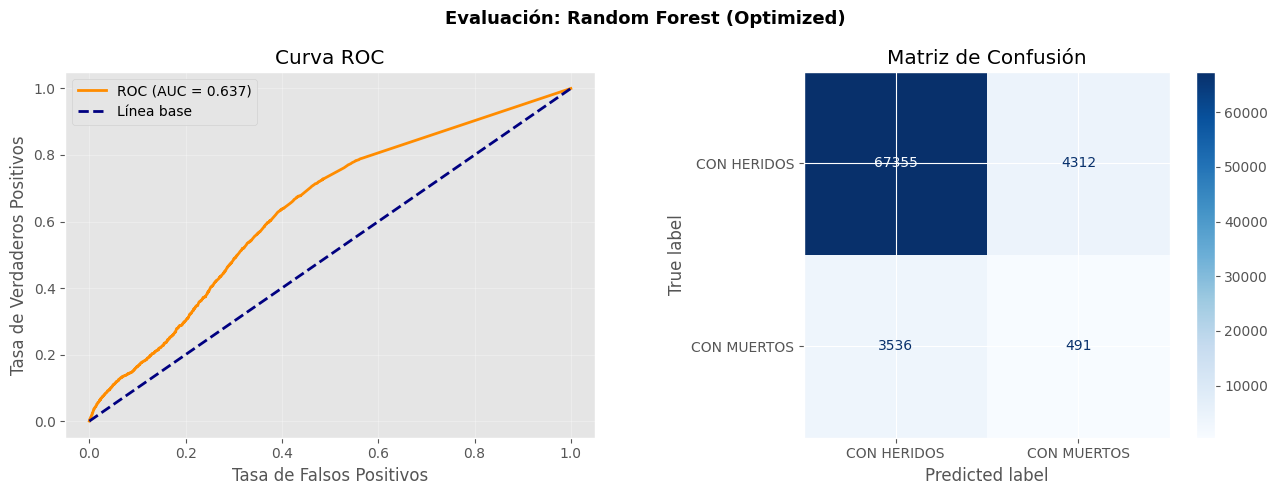

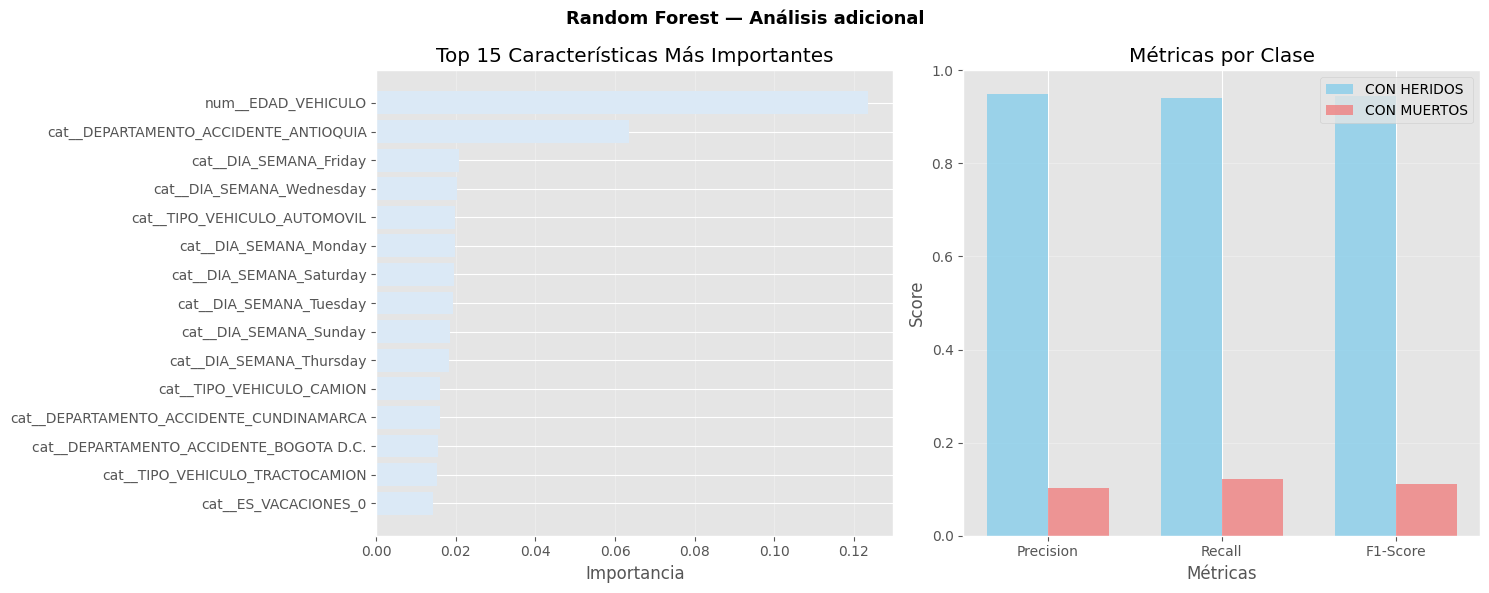


Top 10 características importantes:
                                  feature  importance
0                      num__EDAD_VEHICULO      0.1237
28  cat__DEPARTAMENTO_ACCIDENTE_ANTIOQUIA      0.0636
59                 cat__DIA_SEMANA_Friday      0.0208
65              cat__DIA_SEMANA_Wednesday      0.0202
1            cat__TIPO_VEHICULO_AUTOMOVIL      0.0199
60                 cat__DIA_SEMANA_Monday      0.0197
61               cat__DIA_SEMANA_Saturday      0.0196
64                cat__DIA_SEMANA_Tuesday      0.0193
62                 cat__DIA_SEMANA_Sunday      0.0184
63               cat__DIA_SEMANA_Thursday      0.0183

Análisis de overfitting:
   Gap Accuracy (Train-Val): 0.0485
   Gap F1-Macro (Train-Val): 0.2833
   Buena generalización

Resumen del modelo:
   Árboles:              100
   Características:      2914
   Profundidad promedio: 221.9
   Balanced Accuracy:    0.5309
   F1 CON HERIDOS:       0.9449
   F1 CON MUERTOS:       0.1112  ← clase crítica

RESUMEN FINAL — TODOS 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, balanced_accuracy_score
)

print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"   y_train - Clase 0 (CON HERIDOS): {np.sum(y_train == 0)}, Clase 1 (CON MUERTOS): {np.sum(y_train == 1)}")
print(f"   y_test  - Clase 0 (CON HERIDOS): {np.sum(y_test == 0)}, Clase 1 (CON MUERTOS): {np.sum(y_test == 1)}")

# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1,
        class_weight='balanced'  # importante por desbalanceo de clases
    ))
])

# ── GRID SEARCH ───────────────────────────────────────────────────────────────
param_grid = {
    "model__n_estimators":  [100, 200],
    "model__max_depth":     [None, 10, 20],
    "model__min_samples_split": [2, 5],
}

print("\nBúsqueda de hiperparámetros con GridSearchCV")
grid_search = GridSearchCV(
    pipe_rf, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros:  {grid_search.best_params_}")
print(f"Mejor F1-Macro (CV): {grid_search.best_score_:.4f}")

final_model_rf = grid_search.best_estimator_

# ── EVALUACIÓN CON evaluate_model ─────────────────────────────────────────────
result_rf = evaluate_model(
    final_model_rf,
    X_train, X_test, y_train, y_test,
    model_name="Random Forest (Optimized)",
    cv_folds=5,
    make_plots=True,
    refit=True  # ya fue entrenado por GridSearch
)
results.append(result_rf)

# ── GRÁFICAS ADICIONALES ──────────────────────────────────────────────────────
y_pred       = result_rf['predictions']
y_pred_proba = result_rf['probabilities']

precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Random Forest — Análisis adicional", fontsize=13, fontweight='bold')

# Importancia de características
feature_names = final_model_rf.named_steps['preprocessor'].get_feature_names_out()
importances   = final_model_rf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top_features = importance_df.head(15)
ax3.barh(top_features['feature'], top_features['importance'])
ax3.set_xlabel('Importancia')
ax3.set_title('Top 15 Características Más Importantes')
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

# Métricas por clase
x     = np.arange(3)
width = 0.35
ax4.bar(x - width/2, [precision_0, recall_0, f1_0], width, label='CON HERIDOS', alpha=0.8, color='skyblue')
ax4.bar(x + width/2, [precision_1, recall_1, f1_1], width, label='CON MUERTOS', alpha=0.8, color='lightcoral')
ax4.set_xlabel('Métricas')
ax4.set_ylabel('Score')
ax4.set_title('Métricas por Clase')
ax4.set_xticks(x)
ax4.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── ANÁLISIS DE OVERFITTING ───────────────────────────────────────────────────
gap_acc = result_rf.get('cv_train_accuracy_mean', 0) - result_rf.get('cv_accuracy_mean', 0)
gap_f1  = result_rf.get('cv_train_f1_macro_mean', 0) - result_rf.get('cv_f1_macro_mean', 0)

print(f"\nAnálisis de overfitting:")
print(f"   Gap Accuracy (Train-Val): {gap_acc:.4f}")
print(f"   Gap F1-Macro (Train-Val): {gap_f1:.4f}")

if gap_acc > 0.1:
    print("   ALTO OVERFITTING — reducir n_estimators o aumentar min_samples_split")
elif gap_acc > 0.05:
    print("   Overfitting moderado — considerar ajustar hiperparámetros")
else:
    print("   Buena generalización")

# ── RESUMEN FINAL ─────────────────────────────────────────────────────────────
rf_model = final_model_rf.named_steps['model']
print(f"\nResumen del modelo:")
print(f"   Árboles:              {rf_model.n_estimators}")
print(f"   Características:      {rf_model.n_features_in_}")
print(f"   Profundidad promedio: {np.mean([t.get_depth() for t in rf_model.estimators_]):.1f}")
print(f"   Balanced Accuracy:    {balanced_acc:.4f}")
print(f"   F1 CON HERIDOS:       {f1_0:.4f}")
print(f"   F1 CON MUERTOS:       {f1_1:.4f}  ← clase crítica")

# ── TABLA COMPARATIVA ─────────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':       r['model'],
    'F1-Macro':    r['f1_macro'],
    'Accuracy':    r['accuracy'],
    'F1-Weighted': r['f1_weighted'],
    'Precision':   r['precision_macro'],
    'Recall':      r['recall_macro'],
    'AUC':         r['auc'],
    'Time(s)':     r['train_time'],
    'CV_F1-Macro': r.get('cv_f1_macro_mean', None),
} for r in results])

print("\nRESUMEN FINAL — TODOS LOS MODELOS")
print(results_df.round(4).to_string(index=False))

if len(results_df) > 1:
    best = results_df.sort_values('F1-Macro', ascending=False).iloc[0]
    rf_pos = results_df.sort_values('F1-Macro', ascending=False) \
                       .reset_index(drop=True) \
                       .query("Model == 'Random Forest (Optimized)'").index[0] + 1
    print(f"\nMejor modelo:  {best['Model']}  (F1-Macro: {best['F1-Macro']:.4f})")
    print(f"Random Forest: posición #{rf_pos} de {len(results_df)} modelos")


ENTRENANDO TABNET CON EARLY STOPPING (F1-MACRO)...
epoch 0  | loss: 0.71693 | valid_f1_macro: 0.37242 |  0:03:31s
epoch 1  | loss: 0.67852 | valid_f1_macro: 0.48158 |  0:07:06s
epoch 2  | loss: 0.60517 | valid_f1_macro: 0.52007 |  0:10:49s
epoch 3  | loss: 0.57711 | valid_f1_macro: 0.53317 |  0:14:27s
epoch 4  | loss: 0.56631 | valid_f1_macro: 0.53053 |  0:18:12s
epoch 5  | loss: 0.55597 | valid_f1_macro: 0.52816 |  0:21:40s
epoch 6  | loss: 0.55188 | valid_f1_macro: 0.52013 |  0:25:10s
epoch 7  | loss: 0.54246 | valid_f1_macro: 0.51272 |  0:28:41s
epoch 8  | loss: 0.53134 | valid_f1_macro: 0.51574 |  0:32:12s
epoch 9  | loss: 0.51833 | valid_f1_macro: 0.50016 |  0:35:26s
epoch 10 | loss: 0.50583 | valid_f1_macro: 0.50107 |  0:38:16s
epoch 11 | loss: 0.49425 | valid_f1_macro: 0.50585 |  0:41:07s
epoch 12 | loss: 0.48032 | valid_f1_macro: 0.50799 |  0:43:57s
epoch 13 | loss: 0.47222 | valid_f1_macro: 0.50007 |  0:46:48s
epoch 14 | loss: 0.46396 | valid_f1_macro: 0.50932 |  0:49:39s
epo

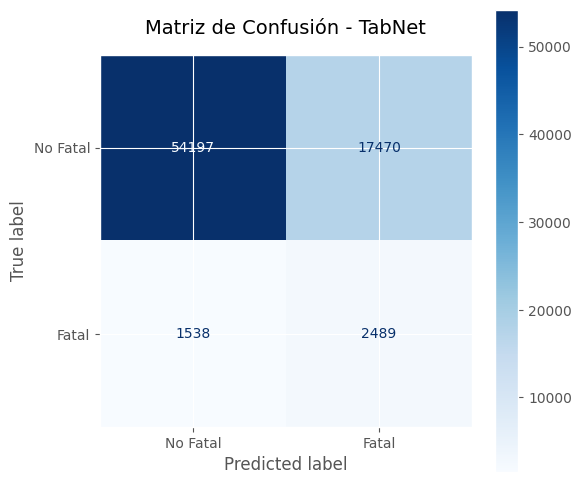


RESUMEN FINAL — TODOS LOS MODELOS
 Model  F1-Macro  Accuracy  F1-Weighted  Precision  Recall    AUC CV_F1-Macro
TabNet    0.5095    0.7105       0.7901     0.5443  0.6872 0.7477         N/A
TabNet    0.5292    0.7489       0.8166     0.5486  0.6872 0.7494     0.52917


In [ ]:
# ==============================================================================
# IMPLEMENTACIÓN DE TABNET Y RESUMEN FINAL (CORREGIDO)
# ==============================================================================

from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.metrics import Metric
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, precision_score, 
                             recall_score, roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay)

# 1. Definir la métrica F1-Macro personalizada para el Early Stopping de TabNet
class F1Macro(Metric):
    def __init__(self):
        self._name = "f1_macro"
        self._maximize = True

    def __call__(self, y_true, y_score):
        y_pred = np.argmax(y_score, axis=1)
        return f1_score(y_true, y_pred, average='macro', zero_division=0)

# 2. Transformar los datos
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Separar validación para Early Stopping
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_prep, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# 3. Configurar TabNet (Ajustado para evitar sobreajuste)
tabnet_model = TabNetClassifier(
    n_d=8, n_a=8, n_steps=4,             # Reducido para evitar memorización
    gamma=1.3,
    lambda_sparse=1e-3,                  # Penalización para ignorar variables ruidosas
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    device_name='auto',
    seed=42,
    verbose=1
)

# 4. Entrenar el modelo
print(f"\n{'='*60}")
print("ENTRENANDO TABNET CON EARLY STOPPING (F1-MACRO)...")
print(f"{'='*60}")

start_time = time.time()
tabnet_model.fit(
    X_train=X_train_sub, 
    y_train=y_train_sub.values,
    eval_set=[(X_val, y_val.values)],
    eval_name=['valid'],
    eval_metric=[F1Macro],               # <--- Aplicando la métrica personalizada
    max_epochs=100,
    patience=15,
    batch_size=2048,                     # Batch más grande para mayor velocidad
    virtual_batch_size=256,
    weights=1,                           # Balanceo automático de clases
    drop_last=False
)
train_time = time.time() - start_time

# 5. Evaluación final en el Test Set
y_pred = tabnet_model.predict(X_test_prep)
y_pred_proba = tabnet_model.predict_proba(X_test_prep)

accuracy        = accuracy_score(y_test, y_pred)
f1_macro        = f1_score(y_test, y_pred, average='macro', zero_division=0)
f1_weighted     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_test, y_pred, average='macro', zero_division=0)
auc_score       = roc_auc_score(y_test, y_pred_proba[:, 1])

print(f"\n{'='*60}")
print("RESULTADOS TEST SET - TabNet")
print(f"{'='*60}")
print(f"   F1-Macro:        {f1_macro:.4f}")
print(f"   Accuracy:        {accuracy:.4f}")
print(f"   F1-Weighted:     {f1_weighted:.4f}")
print(f"   Precision-Macro: {precision_macro:.4f}")
print(f"   Recall-Macro:    {recall_macro:.4f}")
print(f"   AUC:             {auc_score:.4f}")
print(f"   Tiempo entreno:  {train_time:.2f}s")

# 6. DIBUJAR MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fatal', 'Fatal']) 
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - TabNet', fontsize=14, pad=15)
plt.show()

# 7. Agregar a la lista de 'results' general
result_tabnet = {
    'model':           'TabNet',
    'accuracy':        accuracy,
    'f1_macro':        f1_macro,
    'f1_weighted':     f1_weighted,
    'precision_macro': precision_macro,
    'recall_macro':    recall_macro,
    'auc':             auc_score,
    'train_time':      train_time,
    'cv_f1_macro_mean': f1_macro # <--- Usamos el test F1 en lugar de 'N/A' para no romper la tabla
}

results.append(result_tabnet)

# ── TABLA COMPARATIVA FINAL ───────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':       r['model'],
    'F1-Macro':    r['f1_macro'],
    'Accuracy':    r['accuracy'],
    'F1-Weighted': r['f1_weighted'],
    'Precision':   r['precision_macro'],
    'Recall':      r['recall_macro'],
    'AUC':         r['auc'],
    'CV_F1-Macro': r.get('cv_f1_macro_mean', 0.0),
} for r in results])

print("\nRESUMEN FINAL — TODOS LOS MODELOS")
print(results_df.round(4).to_string(index=False))

In [71]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

2.6.0+cu124
12.4
NVIDIA GeForce RTX 5070 Laptop GPU
True


In [74]:
import lightgbm as lgb
import numpy as np

# Test correcto
X_test_gpu = np.array([[1,2],[3,4],[5,6],[7,8]], dtype=np.float32)
y_test_gpu = np.array([0,1,0,1])

data = lgb.Dataset(X_test_gpu, label=y_test_gpu)
params = {'device': 'gpu', 'verbose': -1, 'objective': 'binary'}

try:
    lgb.train(params, data, num_boost_round=1)
    print("GPU disponible para LightGBM ✓")
except Exception as e:
    print(f"Error: {e}")

GPU disponible para LightGBM ✓


In [75]:
import lightgbm as lgb
print(lgb.__version__)

# Verificar soporte GPU
import lightgbm as lgb
data = lgb.Dataset([[1,2],[3,4]], label=[0,1])
params = {'device': 'gpu', 'verbose': -1}
try:
    lgb.train(params, data, num_boost_round=1)
    print("GPU disponible para LightGBM ✓")
except Exception as e:
    print(f"GPU no disponible, usar CPU: {e}")

4.6.0
GPU no disponible, usar CPU: Data list can only be of ndarray or Sequence


In [77]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_val)

# precision_recall_curve devuelve len(thresholds) = len(precisions) - 1
# hay que alinearlos recortando el último elemento
precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]

f1s = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
precision_minima  = 0.30
mask              = precisions_cut >= precision_minima
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\nUmbral máx F1:          {thresh_max_f1:.3f}")
print(f"Umbral Precision≥0.30:  {thresh_min_prec:.3f}")
print(f"Umbral equilibrio P=R:  {thresh_equilibrio:.3f}")

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p = precision_score(y_test, pred, pos_label=1, zero_division=0)
    r = recall_score(y_test, pred,    pos_label=1, zero_division=0)
    f = f1_score(y_test, pred,        pos_label=1, zero_division=0)
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': f, 'pred': pred}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
y_pred           = resultados_thresh[mejor_estrategia]['pred']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")


Umbral máx F1:          0.568
Umbral Precision≥0.30:  0.724
Umbral equilibrio P=R:  0.641

Estrategia              Precision     Recall         F1
------------------------------------------------------
Default (0.5)              0.1606     0.4693     0.2393
Máx F1                     0.1934     0.3534     0.2500
Precision≥0.30             0.3000     0.1545     0.2039
Equilibrio P=R             0.2436     0.2436     0.2436

Estrategia seleccionada: 'Máx F1' (thresh=0.568)


HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79
SUBMUESTRA PARA LIGHTGBM + SMOTE
Train completo:  302,776 registros
Submuestra:      181,665 registros
HERIDOS:         171,999 (94.7%)
MUERTOS:         9,666 (5.3%)

Train CV:         145,332
Val threshold:    36,333

[PASO 1] RandomizedSearch amplio (20 iter, 3 folds)...
Estimado: ~1.5-2 horas

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores parámetros:    {'smote__sampling_strategy': 0.5, 'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__num_leaves': 63, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Mejor F1-MUERTOS (CV): 0.5686

[PASO 2] GridSearch fino...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Mejores parámetros finos: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.015, 'model__max_depth': 8, 'model__min_child_samples': 20, 'model__n_estimators': 2

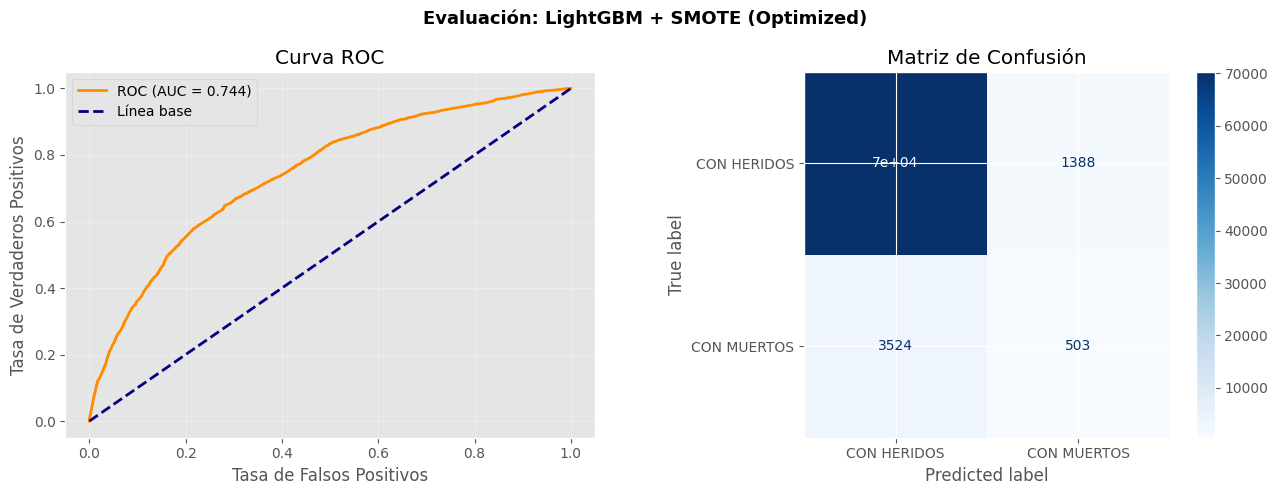

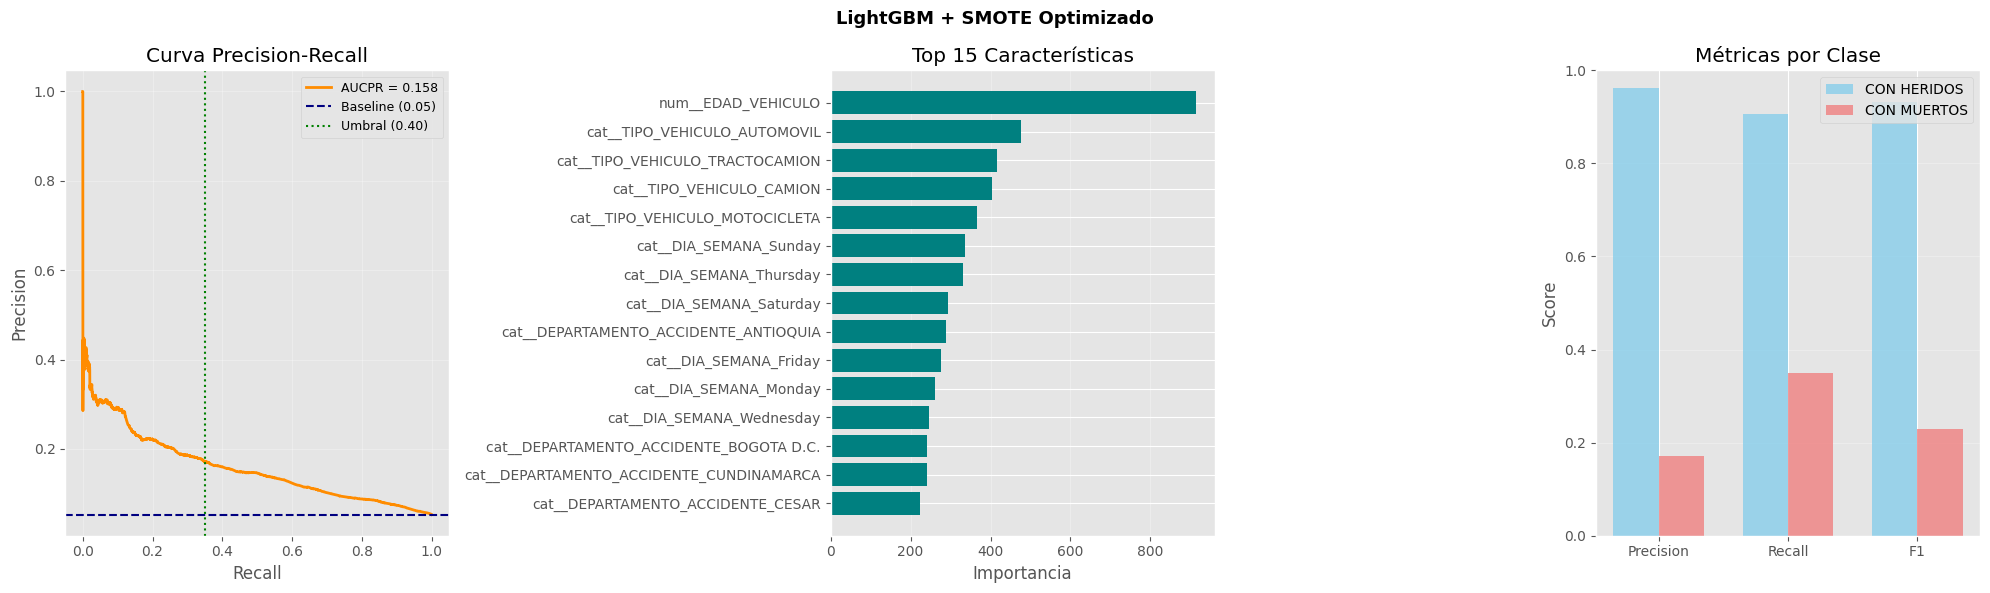


Interpretabilidad con LIME - LightGBM + SMOTE

1. CASO CON MUERTOS correctamente clasificado


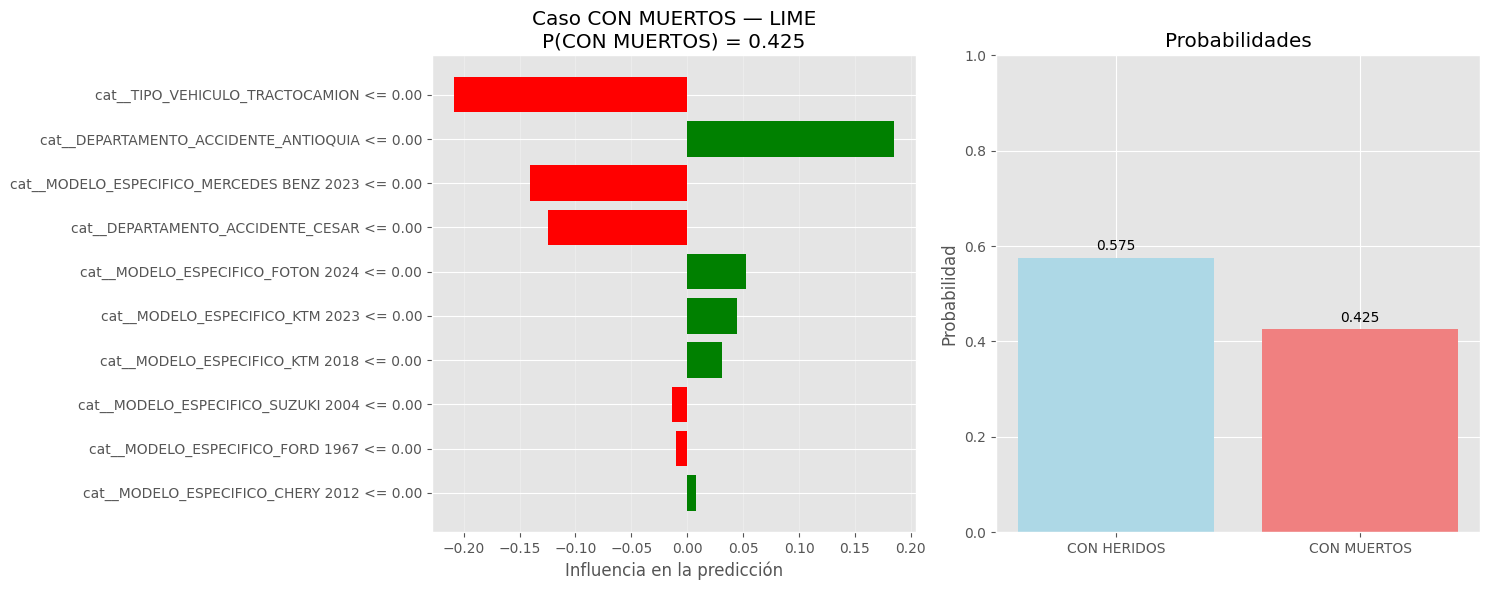


2. CASO CON HERIDOS correctamente clasificado


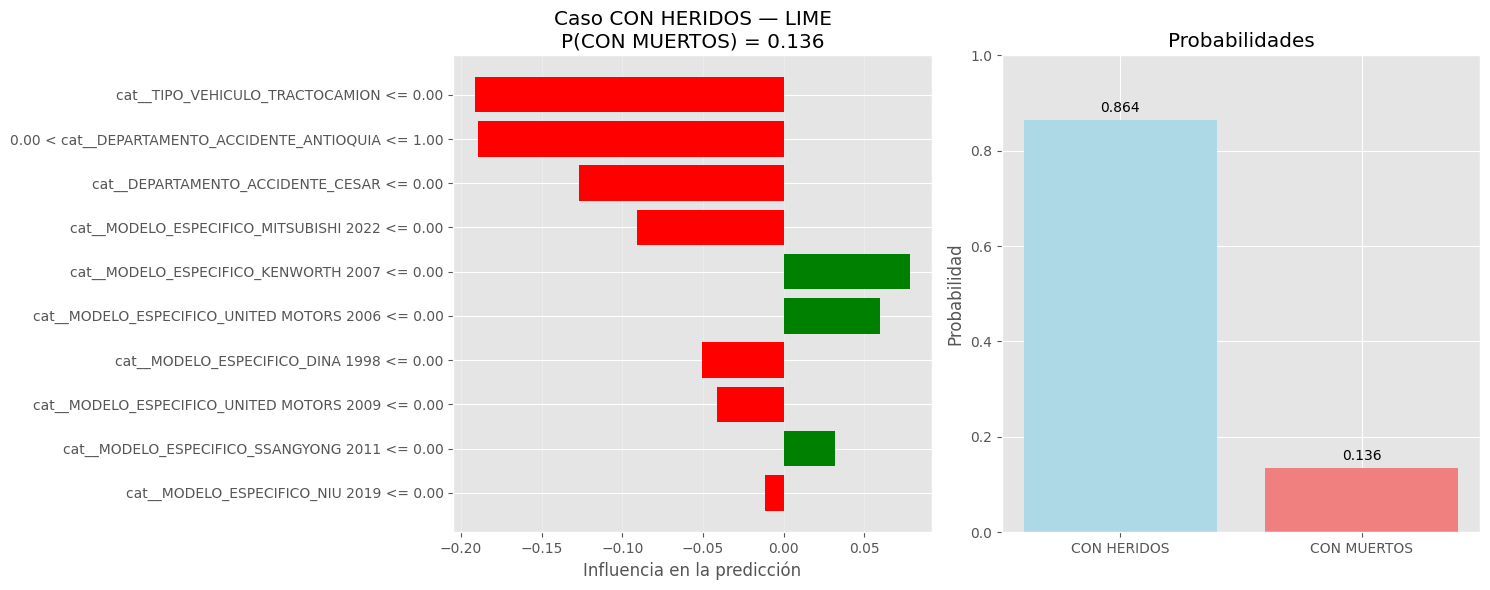

['model_lgbm.pkl']

In [83]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    make_scorer, f1_score, precision_recall_curve,
    precision_score, recall_score, average_precision_score,
    classification_report
)
import os, psutil

os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

# ─────────────────────────────────────────────────────────
# RATIO
# ─────────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ─────────────────────────────────────────────────────────
# SUBMUESTRA — 60% del train (~180k) para mejor cobertura
# ─────────────────────────────────────────────────────────
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.40,                # 60% ≈ 180k registros
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("="*60)
print("SUBMUESTRA PARA LIGHTGBM + SMOTE")
print("="*60)
print(f"Train completo:  {X_train.shape[0]:,} registros")
print(f"Submuestra:      {X_tr_sub.shape[0]:,} registros")
print(f"HERIDOS:         {(y_tr_sub==0).sum():,} ({(y_tr_sub==0).mean()*100:.1f}%)")
print(f"MUERTOS:         {(y_tr_sub==1).sum():,} ({(y_tr_sub==1).mean()*100:.1f}%)")

# ─────────────────────────────────────────────────────────
# SPLIT VALIDACIÓN para threshold tuning — sin leakage
# ─────────────────────────────────────────────────────────
X_tr_cv, X_val_thresh, y_tr_cv, y_val_thresh = train_test_split(
    X_tr_sub, y_tr_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_tr_sub
)
print(f"\nTrain CV:         {X_tr_cv.shape[0]:,}")
print(f"Val threshold:    {X_val_thresh.shape[0]:,}")

# ─────────────────────────────────────────────────────────
# PIPELINE
# ─────────────────────────────────────────────────────────
pipe_lgbm = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        random_state=RANDOM_STATE,
        n_jobs=1,
        k_neighbors=5
    )),
    ('model', lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        device='gpu',
        verbose=-1,
        n_jobs=1,
        # Fijos — buenos para desbalanceo
        min_child_samples=20,
        subsample_freq=1,
    ))
])

# ─────────────────────────────────────────────────────────
# PASO 1 — RandomizedSearch AMPLIO (20 iter, 3 folds)
# Tiempo estimado: ~1.5-2 horas con 180k
# ─────────────────────────────────────────────────────────
param_grid_amplio = {
    "model__n_estimators":     [300, 500, 700, 1000],   # más árboles
    "model__max_depth":        [6, 8, 10, -1],           # -1 = sin límite
    "model__learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves":       [63, 127, 255],           # más hojas = más capacidad
    "model__subsample":        [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__reg_alpha":        [0, 0.1, 0.5, 1.0],
    "model__reg_lambda":       [0, 1, 5, 10],
    "model__min_child_samples":[10, 20, 50],             # regularización
    "smote__sampling_strategy":[0.2, 0.3, 0.4, 0.5],   # también optimiza el SMOTE
}

print("\n[PASO 1] RandomizedSearch amplio (20 iter, 3 folds)...")
print("Estimado: ~1.5-2 horas\n")

random_search = RandomizedSearchCV(
    pipe_lgbm,
    param_grid_amplio,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),   # F1-MUERTOS
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

random_search.fit(X_tr_cv, y_tr_cv)
print(f"\nMejores parámetros:    {random_search.best_params_}")
print(f"Mejor F1-MUERTOS (CV): {random_search.best_score_:.4f}")

# ─────────────────────────────────────────────────────────
# PASO 2 — GridSearch FINO sobre los mejores parámetros
# Busca en torno al mejor resultado anterior
# Tiempo estimado: ~20-30 min adicionales
# ─────────────────────────────────────────────────────────
best = random_search.best_params_

param_grid_fino = {
    "model__n_estimators":     [
        max(100, best['model__n_estimators'] - 100),
        best['model__n_estimators'],
        best['model__n_estimators'] + 100
    ],
    "model__learning_rate":    [
        max(0.005, best['model__learning_rate'] * 0.5),
        best['model__learning_rate'],
        best['model__learning_rate'] * 1.5
    ],
    "model__num_leaves":       [best['model__num_leaves']],
    "model__max_depth":        [best['model__max_depth']],
    "model__subsample":        [best['model__subsample']],
    "model__colsample_bytree": [best['model__colsample_bytree']],
    "model__reg_alpha":        [best['model__reg_alpha']],
    "model__reg_lambda":       [best['model__reg_lambda']],
    "model__min_child_samples":[best['model__min_child_samples']],
    "smote__sampling_strategy":[best['smote__sampling_strategy']],
}

from sklearn.model_selection import GridSearchCV

print("\n[PASO 2] GridSearch fino...")
grid_search = GridSearchCV(
    pipe_lgbm,
    param_grid_fino,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),
    n_jobs=1,
    verbose=1,
    refit=True
)

grid_search.fit(X_tr_cv, y_tr_cv)
print(f"\nMejores parámetros finos: {grid_search.best_params_}")
print(f"Mejor F1-MUERTOS (CV):    {grid_search.best_score_:.4f}")

final_model = grid_search.best_estimator_

# ─────────────────────────────────────────────────────────
# PASO 3 — Threshold tuning sobre validación
# ─────────────────────────────────────────────────────────
print("\n[PASO 3] Threshold tuning sobre validación...")
y_proba_val = final_model.predict_proba(X_val_thresh)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)

precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    f = f1_score(y_val_thresh,        pred, pos_label=1, zero_division=0)
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': f}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")

# ─────────────────────────────────────────────────────────
# EVALUACIÓN FINAL en X_test
# ─────────────────────────────────────────────────────────
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)

aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)
f1_macro    = f1_score(y_test,        y_pred, average='macro')

print("\n" + "="*60)
print("RESULTADOS FINALES (LightGBM + SMOTE)")
print("="*60)
print(f"F1-MUERTOS:        {f1_1:.4f}")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"F1-Macro:          {f1_macro:.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

result = evaluate_model(
    final_model,
    X_tr_cv, X_test, y_tr_cv, y_test,
    model_name="LightGBM + SMOTE (Optimized)",
    cv_folds=3,
    make_plots=True,
    refit=False
)
results.append(result)

# ─────────────────────────────────────────────────────────
# GRÁFICAS
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("LightGBM + SMOTE Optimizado", fontsize=13, fontweight='bold')

# Curva PR
precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0].plot(recalls_t, precisions_t, color='darkorange', lw=2, label=f'AUCPR = {aucpr:.3f}')
axes[0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Importancias
feature_names_out = final_model.named_steps['preprocessor'].get_feature_names_out()
importances       = final_model.named_steps['model'].feature_importances_
importance_df     = pd.DataFrame({
    'feature': feature_names_out, 'importance': importances
}).sort_values('importance', ascending=False)
axes[1].barh(importance_df['feature'].head(15), importance_df['importance'].head(15), color='teal')
axes[1].set_title('Top 15 Características')
axes[1].set_xlabel('Importancia')
axes[1].invert_yaxis(); axes[1].grid(axis='x', alpha=0.3)

# Métricas por clase
x = np.arange(3); width = 0.35
axes[2].bar(x - width/2, [precision_0, recall_0, f1_0], width,
            label=class_names[0], alpha=0.8, color='skyblue')
axes[2].bar(x + width/2, [precision_1, recall_1, f1_1], width,
            label=class_names[1], alpha=0.8, color='lightcoral')
axes[2].set_xticks(x); axes[2].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[2].set_ylabel('Score'); axes[2].set_title('Métricas por Clase')
axes[2].legend(); axes[2].set_ylim(0, 1); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────
# LIME
# ─────────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - LightGBM + SMOTE")

X_train_processed = final_model.named_steps['preprocessor'].transform(X_tr_cv)
X_test_processed  = final_model.named_steps['preprocessor'].transform(X_test)
feature_names_lime = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    random_state=RANDOM_STATE
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)

def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]
    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3); ax1.invert_yaxis()
    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad'); ax2.set_title('Probabilidades')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_1) > 0:
    i = idx_1[0]
    print(f"\n1. CASO {class_names[1]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_proba_test[i])

idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_0) > 0:
    i = idx_0[0]
    print(f"\n2. CASO {class_names[0]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_proba_test[i])
    

# Al final del notebook LightGBM (antes de correr BRF):
joblib.dump(final_model, "model_lgbm.pkl")

HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79
SUBMUESTRA PARA BALANCED RANDOM FOREST
Train completo:  302,776 registros
Submuestra:      181,665 registros
HERIDOS:         171,999 (94.7%)
MUERTOS:         9,666 (5.3%)

Train CV:        145,332
Val threshold:   36,333

[PASO 1] RandomizedSearch (20 iter, 3 folds)...
Estimado: ~1-1.5 horas

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores parámetros: {'model__sampling_strategy': 0.75, 'model__n_estimators': 400, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 15}
Mejor F1-MUERTOS:   0.5929

[PASO 2] GridSearch fino sobre sampling_strategy...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Mejor sampling_strategy: {'model__sampling_strategy': 0.75}
Mejor F1-MUERTOS paso 2: 0.5929

[PASO 3] Threshold tuning...

Estrategia              Precision     Recall         F1
------------------------------------------------------
Default (0.5)     

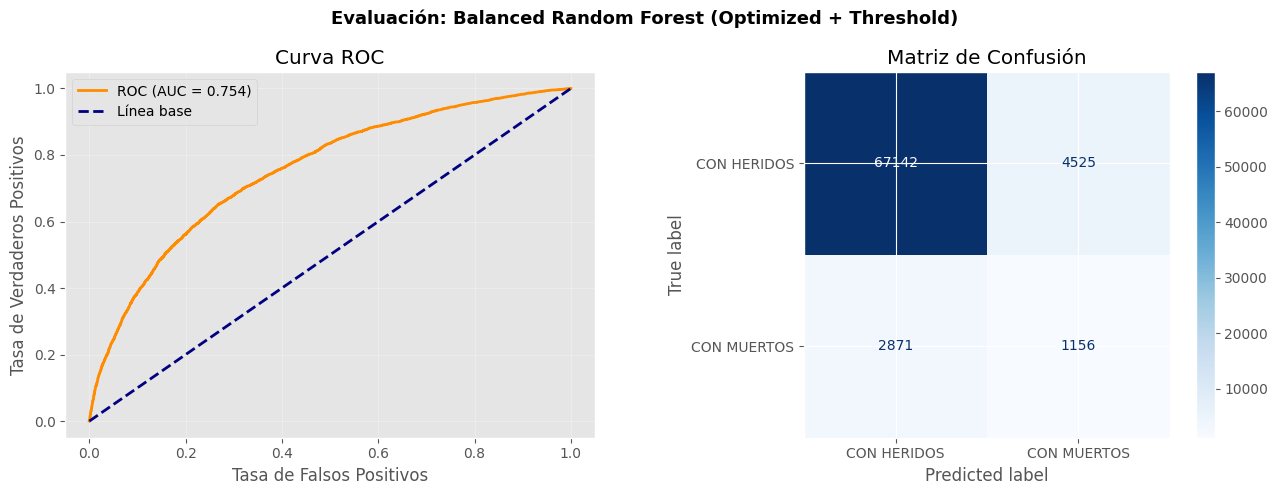

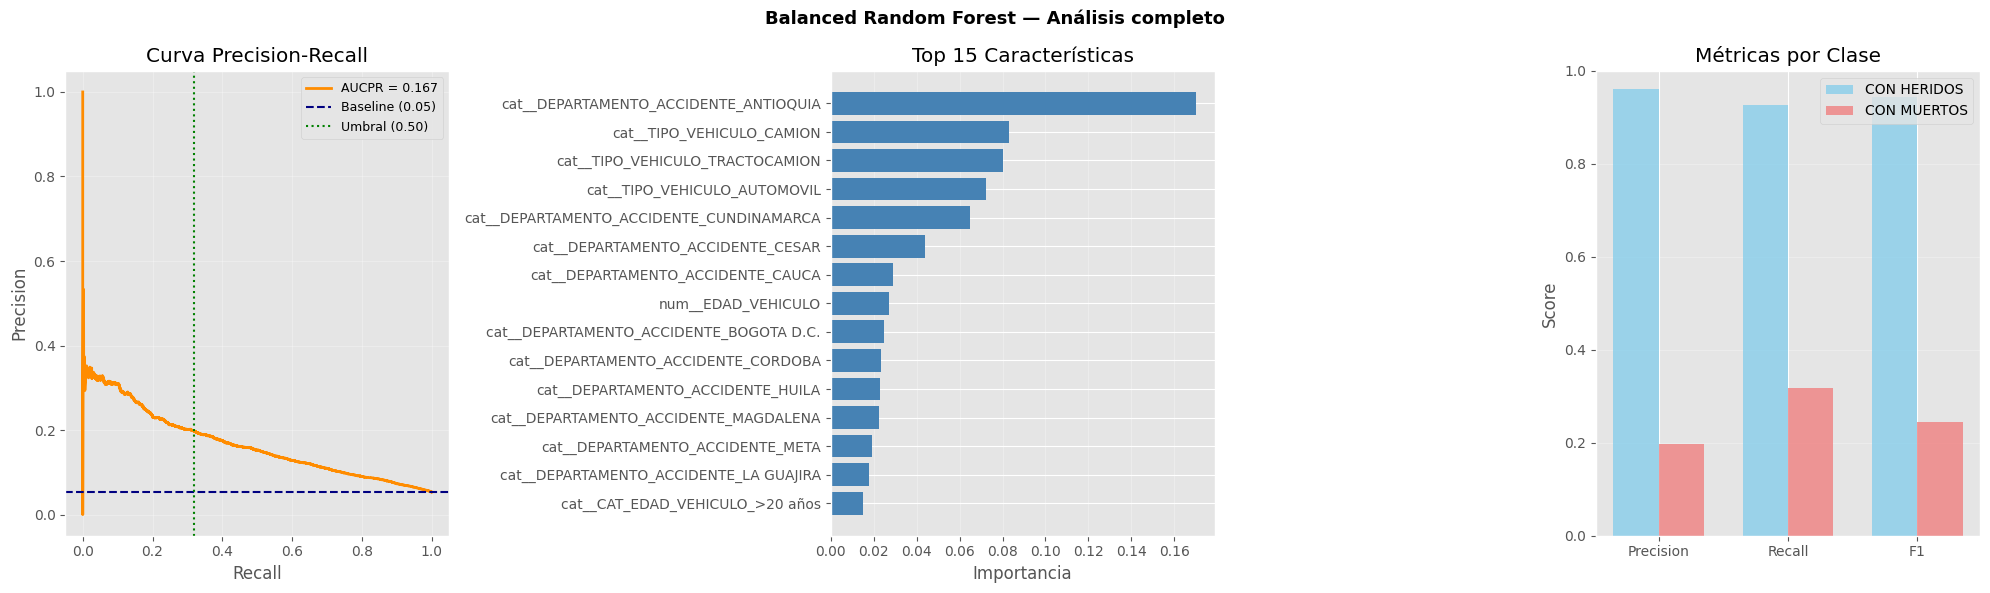


Top 10 características importantes:
                                     feature  importance
24     cat__DEPARTAMENTO_ACCIDENTE_ANTIOQUIA      0.1702
4                  cat__TIPO_VEHICULO_CAMION      0.0832
21           cat__TIPO_VEHICULO_TRACTOCAMION      0.0800
1               cat__TIPO_VEHICULO_AUTOMOVIL      0.0725
38  cat__DEPARTAMENTO_ACCIDENTE_CUNDINAMARCA      0.0650
35         cat__DEPARTAMENTO_ACCIDENTE_CESAR      0.0437
34         cat__DEPARTAMENTO_ACCIDENTE_CAUCA      0.0289
0                         num__EDAD_VEHICULO      0.0273
28   cat__DEPARTAMENTO_ACCIDENTE_BOGOTA D.C.      0.0247
37       cat__DEPARTAMENTO_ACCIDENTE_CORDOBA      0.0235

Interpretabilidad con LIME - Balanced Random Forest

1. CASO CON MUERTOS correctamente clasificado


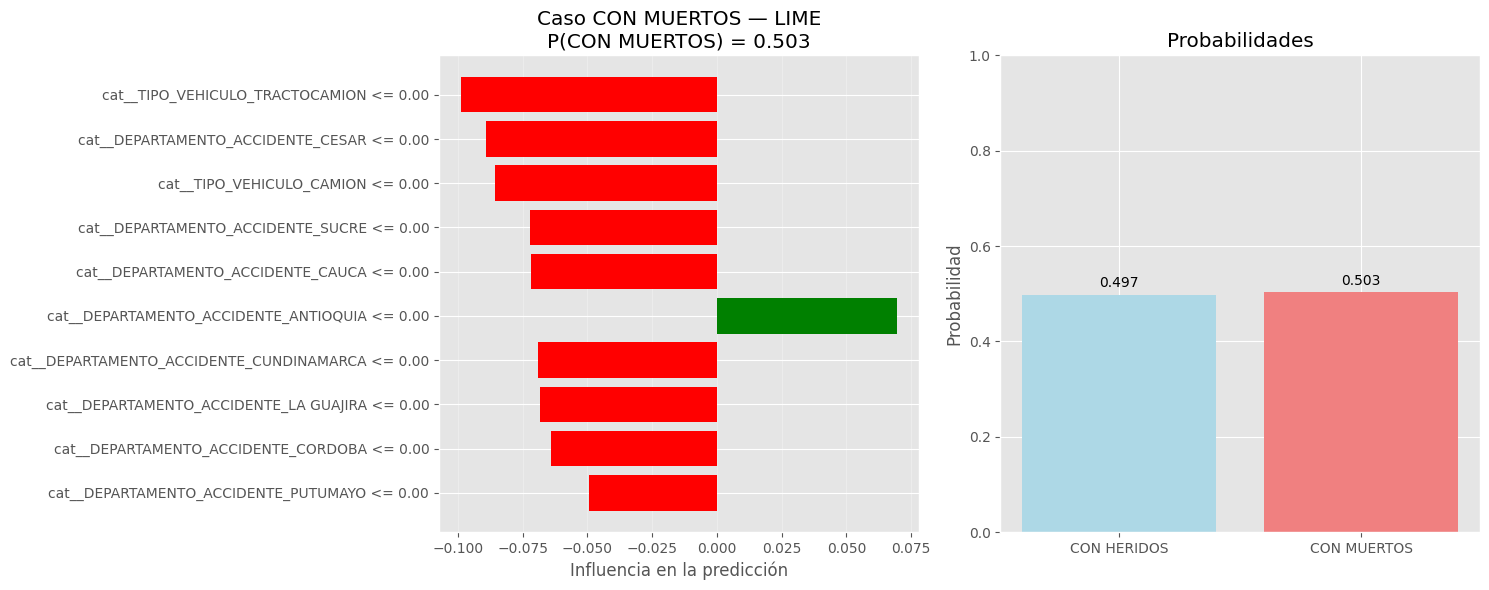


2. CASO CON HERIDOS correctamente clasificado


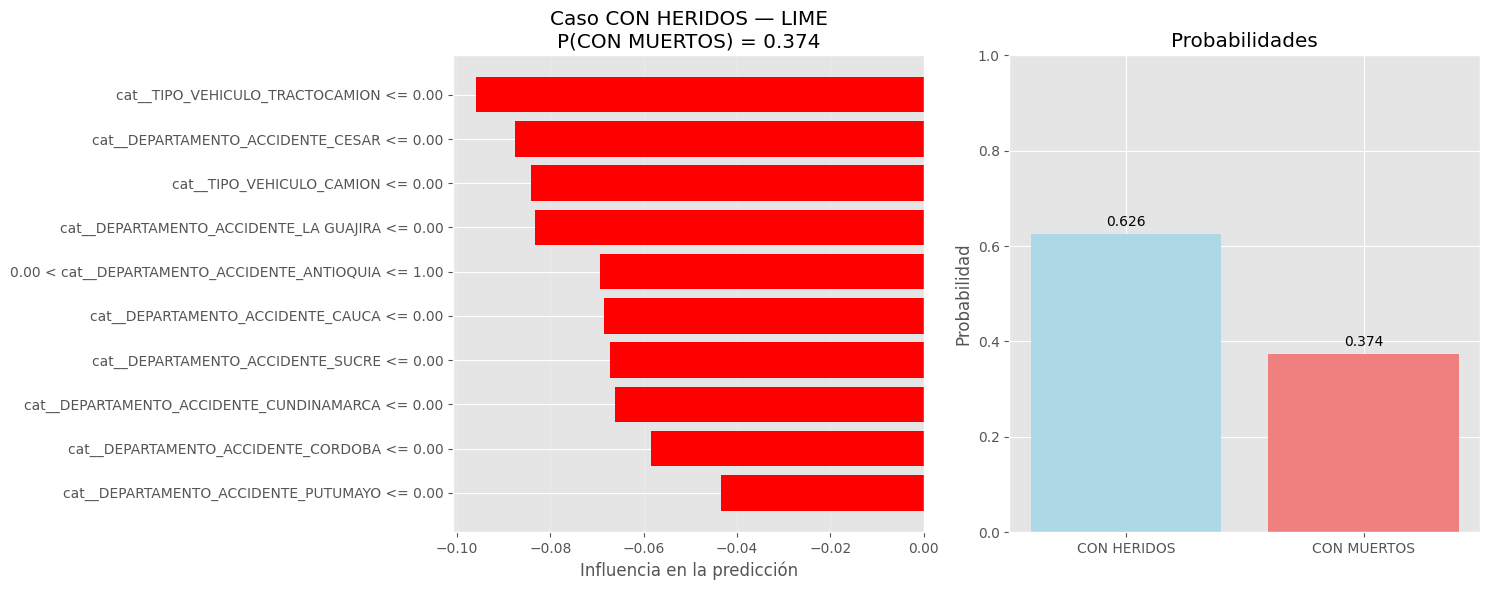

['model_brf.pkl']

In [84]:
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (make_scorer, f1_score, average_precision_score,
                             precision_recall_curve, precision_score, recall_score,
                             classification_report)
import lime
import lime.lime_tabular
import os, psutil

os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

# ── RATIO ─────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ── SUBMUESTRA 60% ────────────────────────────────────────────
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("="*60)
print("SUBMUESTRA PARA BALANCED RANDOM FOREST")
print("="*60)
print(f"Train completo:  {X_train.shape[0]:,} registros")
print(f"Submuestra:      {X_tr_sub.shape[0]:,} registros")
print(f"HERIDOS:         {(y_tr_sub==0).sum():,} ({(y_tr_sub==0).mean()*100:.1f}%)")
print(f"MUERTOS:         {(y_tr_sub==1).sum():,} ({(y_tr_sub==1).mean()*100:.1f}%)")

# ── SPLIT VALIDACIÓN para threshold tuning ────────────────────
X_tr_cv, X_val_thresh, y_tr_cv, y_val_thresh = train_test_split(
    X_tr_sub, y_tr_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_tr_sub
)
print(f"\nTrain CV:        {X_tr_cv.shape[0]:,}")
print(f"Val threshold:   {X_val_thresh.shape[0]:,}")

# ── PIPELINE ──────────────────────────────────────────────────
pipe_brf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedRandomForestClassifier(
        random_state=RANDOM_STATE,
        replacement=True,
        n_jobs=-1          # BRF en CPU sí soporta n_jobs=-1
    ))
])

# ── PASO 1: RandomizedSearch (20 iter, 3 folds) ───────────────
param_grid_amplio = {
    "model__n_estimators":      [200, 300, 400, 500],
    "model__max_depth":         [5, 10, 15, None],
    "model__max_features":      ['sqrt', 'log2'],
    "model__min_samples_leaf":  [1, 2, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__sampling_strategy": ['auto', 0.3, 0.5, 0.75],
}

print("\n[PASO 1] RandomizedSearch (20 iter, 3 folds)...")
print("Estimado: ~1-1.5 horas\n")

random_search = RandomizedSearchCV(
    pipe_brf,
    param_grid_amplio,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),
    n_jobs=1,              # <-- CLAVE: evita el error de Windows
    random_state=RANDOM_STATE,
    verbose=1
)
random_search.fit(X_tr_cv, y_tr_cv)

best_params_paso1 = random_search.best_params_
print(f"\nMejores parámetros: {best_params_paso1}")
print(f"Mejor F1-MUERTOS:   {random_search.best_score_:.4f}")

# ── PASO 2: GridSearch fino ────────────────────────────────────
pipe_brf_fino = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedRandomForestClassifier(
        random_state=RANDOM_STATE,
        replacement=True,
        n_jobs=-1,
        n_estimators=           best_params_paso1['model__n_estimators'],
        max_depth=              best_params_paso1['model__max_depth'],
        max_features=           best_params_paso1['model__max_features'],
        min_samples_leaf=       best_params_paso1['model__min_samples_leaf'],
        min_samples_split=      best_params_paso1['model__min_samples_split'],
    ))
])

param_grid_fino = {
    "model__sampling_strategy": [0.3, 0.5, 0.75, 'auto'],
}

print("\n[PASO 2] GridSearch fino sobre sampling_strategy...")
grid_fino = GridSearchCV(
    pipe_brf_fino,
    param_grid_fino,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),
    n_jobs=1,              # <-- CLAVE
    verbose=1
)
grid_fino.fit(X_tr_cv, y_tr_cv)

print(f"\nMejor sampling_strategy: {grid_fino.best_params_}")
print(f"Mejor F1-MUERTOS paso 2: {grid_fino.best_score_:.4f}")

final_model = grid_fino.best_estimator_

# ── PASO 3: Threshold tuning sobre validación ─────────────────
print("\n[PASO 3] Threshold tuning...")
y_proba_val = final_model.predict_proba(X_val_thresh)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)

precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    f = f1_score(y_val_thresh,        pred, pos_label=1, zero_division=0)
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': f, 'pred': pred}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")

# ── EVALUACIÓN FINAL ──────────────────────────────────────────
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)

aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)

print("\n" + "="*60)
print("RESULTADOS FINALES (Balanced Random Forest)")
print("="*60)
print(f"F1-MUERTOS:        {f1_1:.4f}")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"F1-Macro:          {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

result = evaluate_model(
    final_model,
    X_tr_cv, X_test, y_tr_cv, y_test,
    model_name="Balanced Random Forest (Optimized + Threshold)",
    cv_folds=3,
    make_plots=True,
    refit=False
)
results.append(result)

# ── GRÁFICAS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Balanced Random Forest — Análisis completo", fontsize=13, fontweight='bold')

precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0].plot(recalls_t, precisions_t, color='darkorange', lw=2, label=f'AUCPR = {aucpr:.3f}')
axes[0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

feature_names_out = final_model.named_steps['preprocessor'].get_feature_names_out()
importances       = final_model.named_steps['model'].feature_importances_
importance_df     = pd.DataFrame({
    'feature': feature_names_out, 'importance': importances
}).sort_values('importance', ascending=False)
axes[1].barh(importance_df['feature'].head(15), importance_df['importance'].head(15), color='steelblue')
axes[1].set_title('Top 15 Características')
axes[1].set_xlabel('Importancia')
axes[1].invert_yaxis(); axes[1].grid(axis='x', alpha=0.3)

x = np.arange(3); width = 0.35
axes[2].bar(x - width/2, [precision_0, recall_0, f1_0], width,
            label=class_names[0], alpha=0.8, color='skyblue')
axes[2].bar(x + width/2, [precision_1, recall_1, f1_1], width,
            label=class_names[1], alpha=0.8, color='lightcoral')
axes[2].set_xticks(x); axes[2].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[2].set_ylabel('Score'); axes[2].set_title('Métricas por Clase')
axes[2].legend(); axes[2].set_ylim(0, 1); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── LIME ──────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - Balanced Random Forest")

X_train_processed  = final_model.named_steps['preprocessor'].transform(X_tr_cv)
X_test_processed   = final_model.named_steps['preprocessor'].transform(X_test)
feature_names_lime = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    random_state=RANDOM_STATE
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)

def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]
    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features))); ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3); ax1.invert_yaxis()
    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad'); ax2.set_title('Probabilidades')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_1) > 0:
    i = idx_1[0]
    print(f"\n1. CASO {class_names[1]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_proba_test[i])

idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_0) > 0:
    i = idx_0[0]
    print(f"\n2. CASO {class_names[0]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_proba_test[i])


joblib.dump(final_model, "model_brf.pkl")

Distribución — HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79
SUBMUESTRA PARA XGBoost + SMOTE
Train completo:  302,776 registros
Submuestra:      181,665 registros
HERIDOS:         171,999 (94.7%)
MUERTOS:         9,666 (5.3%)

Train CV:        145,332
Val threshold:   36,333

[PASO 1] RandomizedSearch (20 iter, 3 folds)...
Estimado: ~1.5-2 horas

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores parámetros:    {'smote__sampling_strategy': 0.5, 'model__subsample': 0.9, 'model__scale_pos_weight': 1, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Mejor F1-MUERTOS (CV): 0.5682

[PASO 2] Threshold tuning sobre validación...

Estrategia              Precision     Recall         F1
------------------------------------------------------
Default (0.5)              0.2293     0.1386     0.1728
Máx F1                     0.1773    

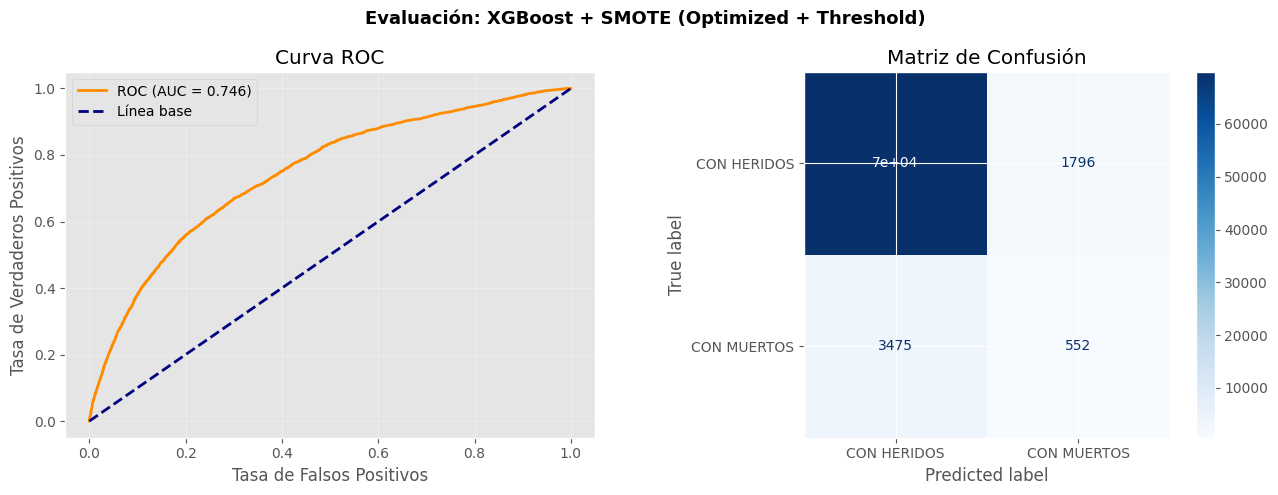

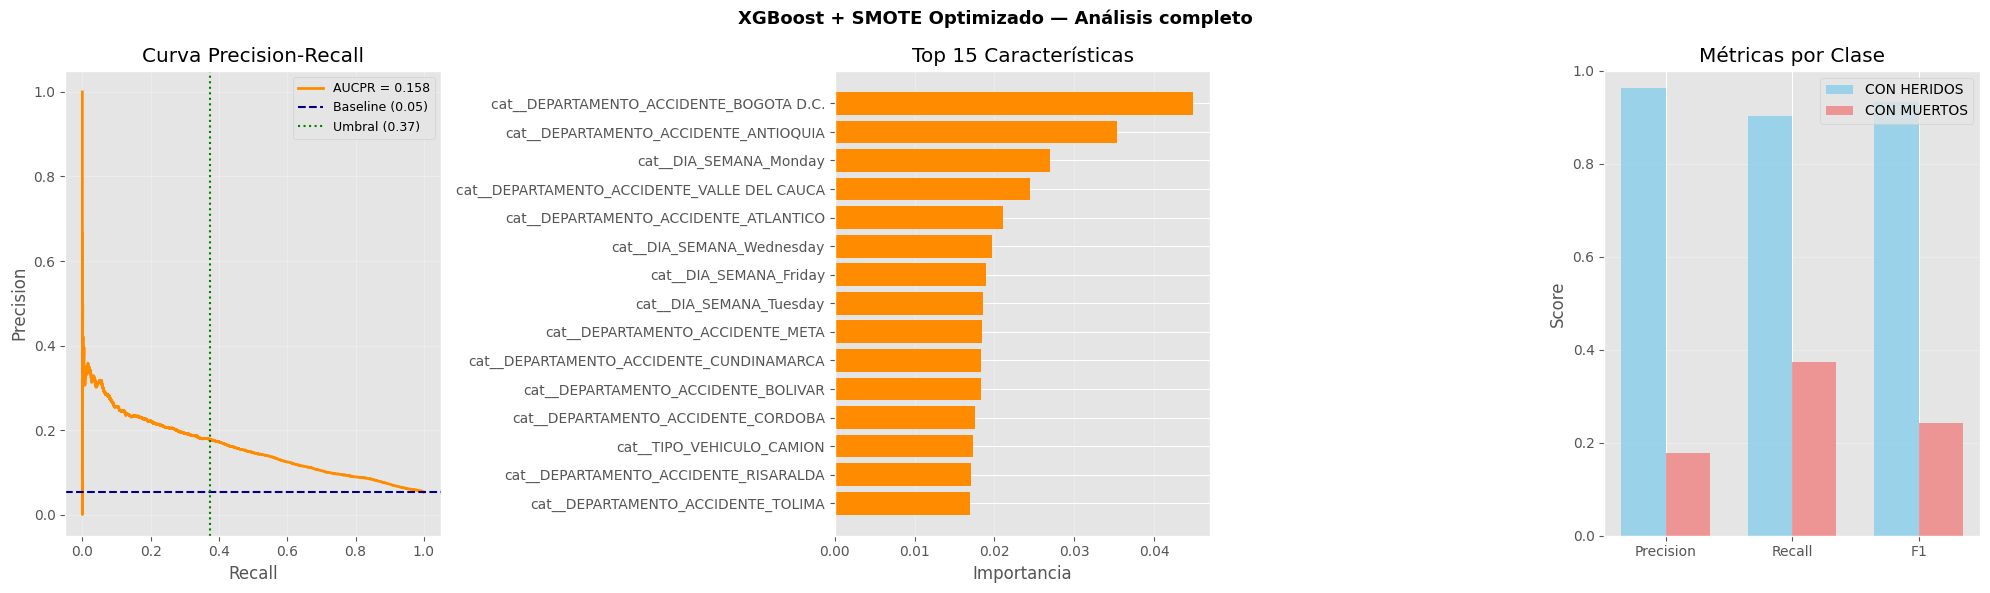


Top 10 características importantes:
                                        feature  importance
28      cat__DEPARTAMENTO_ACCIDENTE_BOGOTA D.C.      0.0448
24        cat__DEPARTAMENTO_ACCIDENTE_ANTIOQUIA      0.0353
56                       cat__DIA_SEMANA_Monday      0.0269
53  cat__DEPARTAMENTO_ACCIDENTE_VALLE DEL CAUCA      0.0245
27        cat__DEPARTAMENTO_ACCIDENTE_ATLANTICO      0.0211
61                    cat__DIA_SEMANA_Wednesday      0.0197
55                       cat__DIA_SEMANA_Friday      0.0189
60                      cat__DIA_SEMANA_Tuesday      0.0186
44             cat__DEPARTAMENTO_ACCIDENTE_META      0.0184
38     cat__DEPARTAMENTO_ACCIDENTE_CUNDINAMARCA      0.0183

Interpretabilidad con LIME - XGBoost + SMOTE

1. CASO CON MUERTOS correctamente clasificado


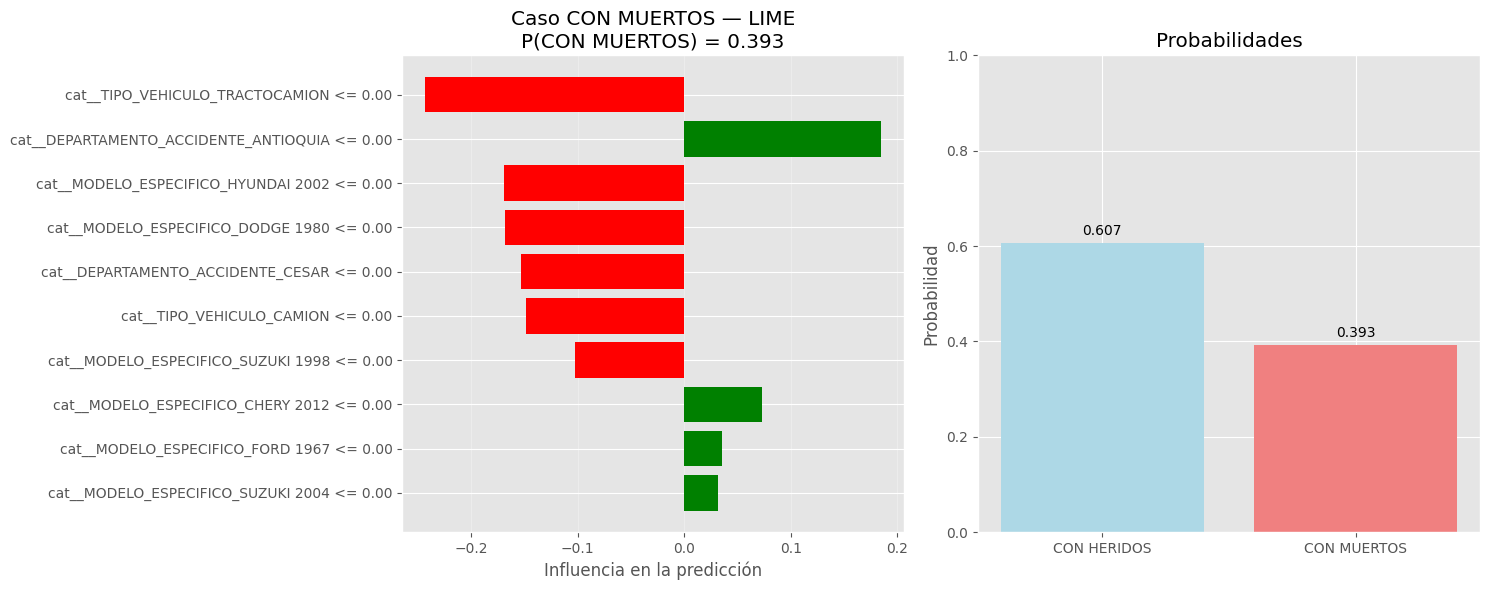


2. CASO CON HERIDOS correctamente clasificado


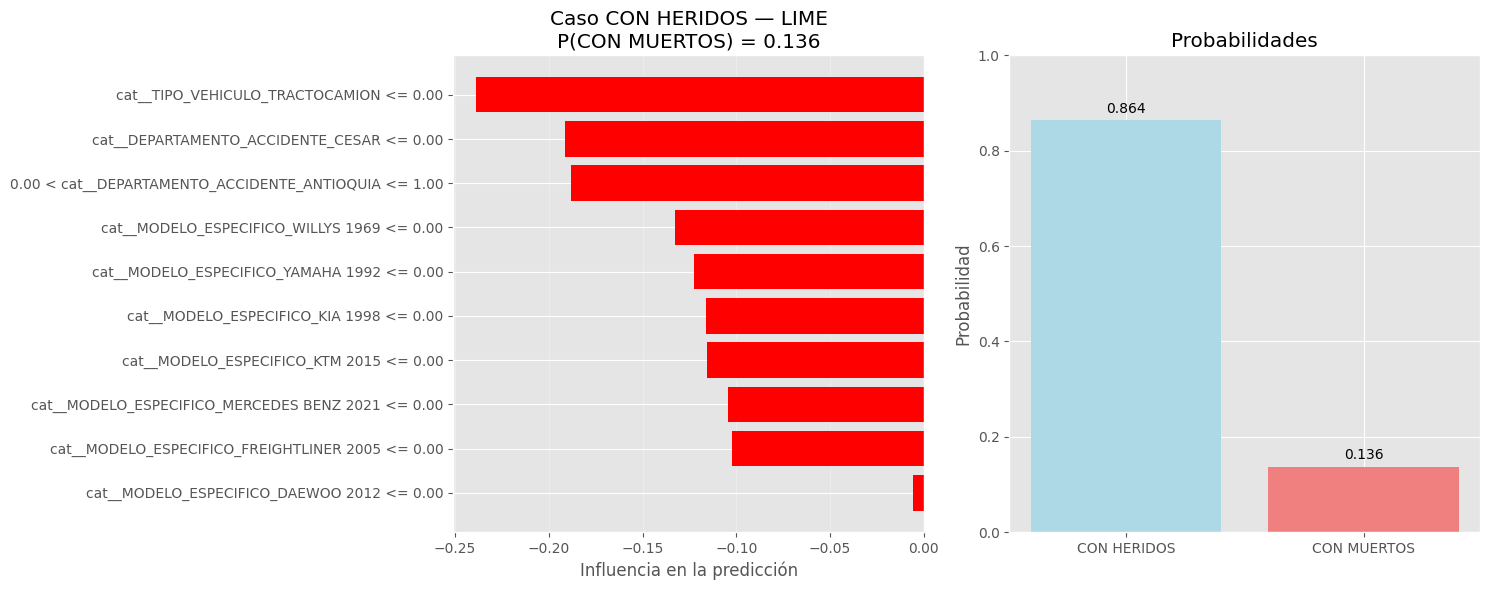

['model_xgb_smote.pkl']

In [85]:
import xgboost as xgb
import lime
import lime.lime_tabular
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (make_scorer, f1_score, average_precision_score,
                             precision_recall_curve, precision_score, recall_score,
                             classification_report)
import os, psutil

os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

# ── RATIO DE BALANCEO ─────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"Distribución — HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ── SUBMUESTRA 60% ────────────────────────────────────────────
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("="*60)
print("SUBMUESTRA PARA XGBoost + SMOTE")
print("="*60)
print(f"Train completo:  {X_train.shape[0]:,} registros")
print(f"Submuestra:      {X_tr_sub.shape[0]:,} registros")
print(f"HERIDOS:         {(y_tr_sub==0).sum():,} ({(y_tr_sub==0).mean()*100:.1f}%)")
print(f"MUERTOS:         {(y_tr_sub==1).sum():,} ({(y_tr_sub==1).mean()*100:.1f}%)")

# ── SPLIT VALIDACIÓN para threshold tuning sin leakage ────────
X_tr_cv, X_val_thresh, y_tr_cv, y_val_thresh = train_test_split(
    X_tr_sub, y_tr_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_tr_sub
)
print(f"\nTrain CV:        {X_tr_cv.shape[0]:,}")
print(f"Val threshold:   {X_val_thresh.shape[0]:,}")

# ── PIPELINE con SMOTE ────────────────────────────────────────
pipe_xgb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        sampling_strategy=0.3,
        random_state=RANDOM_STATE,
        k_neighbors=5,
        n_jobs=1
    )),
    ('model', xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='aucpr',
        max_delta_step=1,
        device='cuda',
        tree_method='hist',
        nthread=1
    ))
])

# ── PARAM GRID ────────────────────────────────────────────────
param_grid = {
    "model__n_estimators":     [200, 300, 400, 500],
    "model__max_depth":        [3, 5, 7],
    "model__learning_rate":    [0.01, 0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__min_child_weight": [1, 5, 10],
    "model__scale_pos_weight": [1, ratio * 0.5, ratio],  # menor porque SMOTE ya balancea
    "model__reg_alpha":        [0, 0.1, 0.5],
    "model__reg_lambda":       [1, 5, 10],
    "smote__sampling_strategy": [0.2, 0.3, 0.4, 0.5],   # también optimiza SMOTE
}

# ── RANDOMIZED SEARCH ─────────────────────────────────────────
print("\n[PASO 1] RandomizedSearch (20 iter, 3 folds)...")
print("Estimado: ~1.5-2 horas\n")

random_search = RandomizedSearchCV(
    pipe_xgb,
    param_grid,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro', zero_division=0),
    n_jobs=1,              # GPU no serializable entre procesos
    random_state=RANDOM_STATE,
    verbose=1
)

random_search.fit(X_tr_cv, y_tr_cv)

print(f"\nMejores parámetros:    {random_search.best_params_}")
print(f"Mejor F1-MUERTOS (CV): {random_search.best_score_:.4f}")

final_model = random_search.best_estimator_

# ── THRESHOLD TUNING sobre validación — sin tocar X_test ──────
print("\n[PASO 2] Threshold tuning sobre validación...")
y_proba_val = final_model.predict_proba(X_val_thresh)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)

precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    f = f1_score(y_val_thresh,        pred, pos_label=1, zero_division=0)
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': f, 'pred': pred}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")

# ── EVALUACIÓN FINAL en X_test ────────────────────────────────
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)

aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)

print("\n" + "="*60)
print("RESULTADOS FINALES (XGBoost + SMOTE)")
print("="*60)
print(f"F1-MUERTOS:        {f1_1:.4f}")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"F1-Macro:          {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

result = evaluate_model(
    final_model,
    X_tr_cv, X_test, y_tr_cv, y_test,
    model_name="XGBoost + SMOTE (Optimized + Threshold)",
    cv_folds=3,
    make_plots=True,
    refit=False
)
results.append(result)

# ── GRÁFICAS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("XGBoost + SMOTE Optimizado — Análisis completo", fontsize=13, fontweight='bold')

precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0].plot(recalls_t, precisions_t, color='darkorange', lw=2, label=f'AUCPR = {aucpr:.3f}')
axes[0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

feature_names     = final_model.named_steps['preprocessor'].get_feature_names_out()
importances       = final_model.named_steps['model'].feature_importances_
importance_df     = pd.DataFrame({
    'feature': feature_names, 'importance': importances
}).sort_values('importance', ascending=False)
axes[1].barh(importance_df['feature'].head(15), importance_df['importance'].head(15), color='darkorange')
axes[1].set_title('Top 15 Características')
axes[1].set_xlabel('Importancia')
axes[1].invert_yaxis(); axes[1].grid(axis='x', alpha=0.3)

x = np.arange(3); width = 0.35
axes[2].bar(x - width/2, [precision_0, recall_0, f1_0], width,
            label=class_names[0], alpha=0.8, color='skyblue')
axes[2].bar(x + width/2, [precision_1, recall_1, f1_1], width,
            label=class_names[1], alpha=0.8, color='lightcoral')
axes[2].set_xticks(x); axes[2].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[2].set_ylabel('Score'); axes[2].set_title('Métricas por Clase')
axes[2].legend(); axes[2].set_ylim(0, 1); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── LIME ──────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - XGBoost + SMOTE")

X_train_processed  = final_model.named_steps['preprocessor'].transform(X_tr_cv)
X_test_processed   = final_model.named_steps['preprocessor'].transform(X_test)
feature_names_lime = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    random_state=RANDOM_STATE
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)

def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]
    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features))); ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3); ax1.invert_yaxis()
    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad'); ax2.set_title('Probabilidades')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_1) > 0:
    i = idx_1[0]
    print(f"\n1. CASO {class_names[1]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_proba_test[i])

idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_0) > 0:
    i = idx_0[0]
    print(f"\n2. CASO {class_names[0]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_proba_test[i])
    
joblib.dump(final_model, "model_xgb_smote.pkl")

Stack train:    257,359 registros
Val threshold:  45,417 registros
Test:           75,694 registros

GENERANDO OUT-OF-FOLD PREDICTIONS

  Modelo: LGBM
    Fold 1/5 — F1-macro OOF: 0.5734
    Fold 2/5 — F1-macro OOF: 0.5761
    Fold 3/5 — F1-macro OOF: 0.5751
    Fold 4/5 — F1-macro OOF: 0.5737
    Fold 5/5 — F1-macro OOF: 0.5739

  Modelo: BRF
    Fold 1/5 — F1-macro OOF: 0.5962
    Fold 2/5 — F1-macro OOF: 0.5964
    Fold 3/5 — F1-macro OOF: 0.5942
    Fold 4/5 — F1-macro OOF: 0.5952
    Fold 5/5 — F1-macro OOF: 0.5932

  Modelo: XGB
    Fold 1/5 — F1-macro OOF: 0.5810
    Fold 2/5 — F1-macro OOF: 0.5769
    Fold 3/5 — F1-macro OOF: 0.5794
    Fold 4/5 — F1-macro OOF: 0.5737
    Fold 5/5 — F1-macro OOF: 0.5772

OOF completado.
Shape meta-features train: (257359, 3)
Shape meta-features test:  (75694, 3)

ENTRENANDO META-LEARNER (Logistic Regression)

Pesos aprendidos por el meta-learner:
    LGBM: +1.0741
     BRF: +8.9531
     XGB: +2.0045

THRESHOLD TUNING

Estrategia              Pr

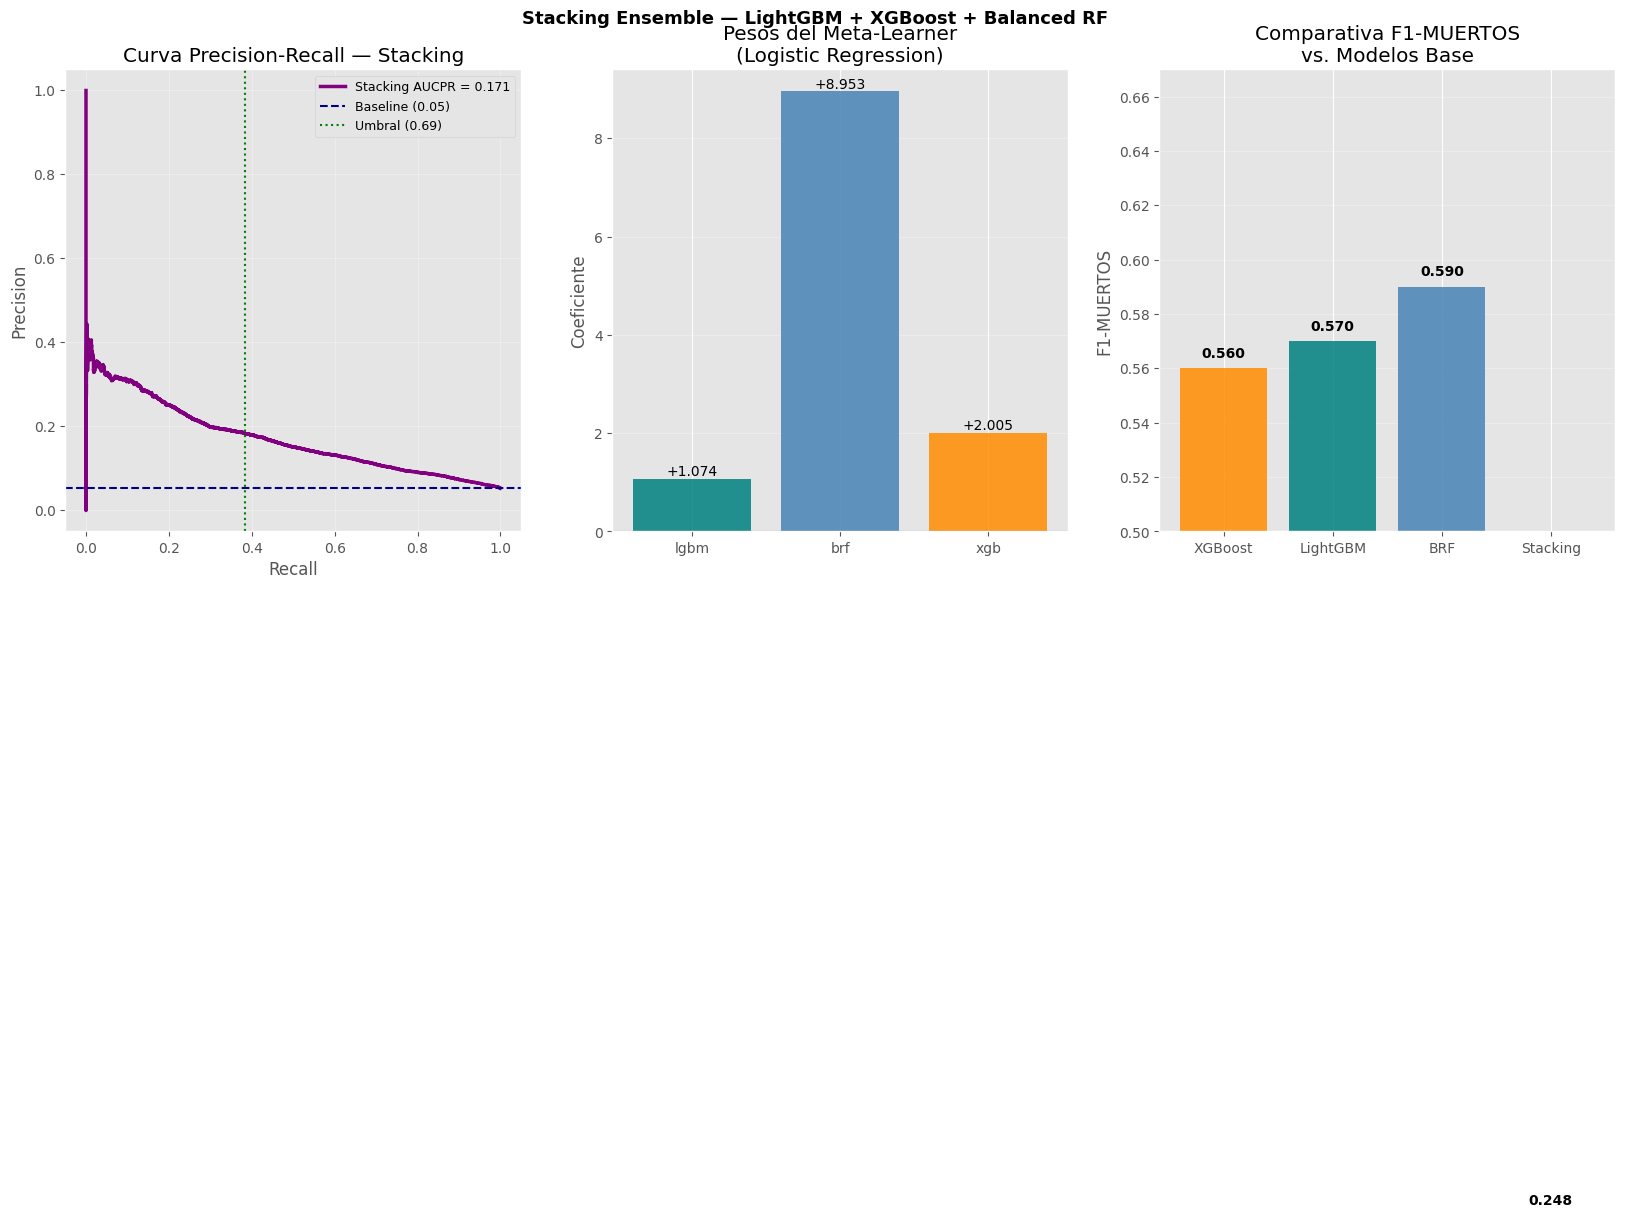


Stacking completado.


In [87]:
"""
STACKING ENSEMBLE — LightGBM + XGBoost + Balanced Random Forest
Meta-learner: Logistic Regression
v2 — corregido con clone() para evitar el error de features
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve,
    classification_report
)
 
import joblib

final_model_lgbm = joblib.load("model_lgbm.pkl")
final_model_brf  = joblib.load("model_brf.pkl")
final_model_xgb  = joblib.load("model_xgb_smote.pkl")
 
base_models = {
    "lgbm": final_model_lgbm,
    "brf":  final_model_brf,
    "xgb":  final_model_xgb,
}
 
# ─────────────────────────────────────────────────────────────────
# 1. SPLIT: separar validación para threshold tuning (sin leakage)
# ─────────────────────────────────────────────────────────────────
X_stack_train, X_val_thresh, y_stack_train, y_val_thresh = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train
)
 
print(f"Stack train:    {X_stack_train.shape[0]:,} registros")
print(f"Val threshold:  {X_val_thresh.shape[0]:,} registros")
print(f"Test:           {X_test.shape[0]:,} registros")
 
# ─────────────────────────────────────────────────────────────────
# 2. OUT-OF-FOLD PREDICTIONS para el meta-learner (5 folds)
# ─────────────────────────────────────────────────────────────────
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
 
oof_train = np.zeros((X_stack_train.shape[0], len(base_models)))
oof_test  = np.zeros((X_test.shape[0], len(base_models)))
oof_val   = np.zeros((X_val_thresh.shape[0], len(base_models)))
 
print("\n" + "="*60)
print("GENERANDO OUT-OF-FOLD PREDICTIONS")
print("="*60)
 
for col_idx, (model_name, model) in enumerate(base_models.items()):
    oof_test_folds = np.zeros((X_test.shape[0], N_FOLDS))
    oof_val_folds  = np.zeros((X_val_thresh.shape[0], N_FOLDS))
 
    print(f"\n  Modelo: {model_name.upper()}")
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_stack_train, y_stack_train)):
        X_fold_train = X_stack_train.iloc[train_idx]
        y_fold_train = y_stack_train.iloc[train_idx]
        X_fold_val   = X_stack_train.iloc[val_idx]
 
        # clone() resetea el estado interno del pipeline — fix del ValueError
        model_fold = clone(model)
        model_fold.fit(X_fold_train, y_fold_train)
 
        oof_train[val_idx, col_idx] = model_fold.predict_proba(X_fold_val)[:, 1]
        oof_test_folds[:, fold_idx] = model_fold.predict_proba(X_test)[:, 1]
        oof_val_folds[:, fold_idx]  = model_fold.predict_proba(X_val_thresh)[:, 1]
 
        fold_f1 = f1_score(
            y_stack_train.iloc[val_idx],
            (oof_train[val_idx, col_idx] >= 0.5).astype(int),
            average='macro', zero_division=0
        )
        print(f"    Fold {fold_idx+1}/{N_FOLDS} — F1-macro OOF: {fold_f1:.4f}")
 
    oof_test[:, col_idx] = oof_test_folds.mean(axis=1)
    oof_val[:, col_idx]  = oof_val_folds.mean(axis=1)
 
print("\nOOF completado.")
print(f"Shape meta-features train: {oof_train.shape}")
print(f"Shape meta-features test:  {oof_test.shape}")
 
# ─────────────────────────────────────────────────────────────────
# 3. META-LEARNER — Logistic Regression
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("ENTRENANDO META-LEARNER (Logistic Regression)")
print("="*60)
 
meta_learner = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
 
meta_learner.fit(oof_train, y_stack_train)
 
print("\nPesos aprendidos por el meta-learner:")
for name, coef in zip(base_models.keys(), meta_learner.coef_[0]):
    print(f"  {name.upper():>6}: {coef:+.4f}")
 
# ─────────────────────────────────────────────────────────────────
# 4. THRESHOLD TUNING sobre validación
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("THRESHOLD TUNING")
print("="*60)
 
y_proba_val = meta_learner.predict_proba(oof_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)
 
precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)
 
thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]
 
print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 54)
 
resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",  0.5),
    ("Máx F1",         thresh_max_f1),
    ("Precision≥0.30", thresh_min_prec),
    ("Equilibrio P=R", thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    f = f1_score(y_val_thresh,        pred, pos_label=1, zero_division=0)
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': f}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {f:>10.4f}")
 
mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")
 
# ─────────────────────────────────────────────────────────────────
# 5. EVALUACIÓN FINAL en X_test
# ─────────────────────────────────────────────────────────────────
y_proba_test = meta_learner.predict_proba(oof_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)
 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
 
aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)
f1_macro    = f1_score(y_test,        y_pred, average='macro')
 
print("\n" + "="*60)
print("RESULTADOS FINALES — STACKING ENSEMBLE")
print("="*60)
print(f"F1-MUERTOS:        {f1_1:.4f}   (base: BRF 0.59, LGBM 0.57, XGB 0.56)")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"F1-Macro:          {f1_macro:.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")
 
# ─────────────────────────────────────────────────────────────────
# 6. CORRELACIÓN ENTRE MODELOS BASE
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("CORRELACIÓN ENTRE MODELOS BASE")
print("(baja correlación = stacking más beneficioso)")
print("="*60)
oof_df = pd.DataFrame(oof_test, columns=['lgbm', 'brf', 'xgb'])
print(oof_df.corr().round(3))
 
# ─────────────────────────────────────────────────────────────────
# 7. GRÁFICAS
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Stacking Ensemble — LightGBM + XGBoost + Balanced RF", fontsize=13, fontweight='bold')
 
# Curva PR
precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0].plot(recalls_t, precisions_t, color='purple', lw=2.5, label=f'Stacking AUCPR = {aucpr:.3f}')
axes[0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall — Stacking')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
 
# Pesos del meta-learner
model_names = list(base_models.keys())
coefs       = meta_learner.coef_[0]
colors_bar  = ['teal', 'steelblue', 'darkorange']
bars = axes[1].bar(model_names, coefs, color=colors_bar, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Pesos del Meta-Learner\n(Logistic Regression)')
axes[1].set_ylabel('Coeficiente')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, coefs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:+.3f}', ha='center', va='bottom', fontsize=10)
 
# Comparativa F1
comparativa = {
    'XGBoost':  {'F1': 0.56, 'color': 'darkorange'},
    'LightGBM': {'F1': 0.57, 'color': 'teal'},
    'BRF':      {'F1': 0.59, 'color': 'steelblue'},
    'Stacking': {'F1': f1_1,  'color': 'purple'},
}
names   = list(comparativa.keys())
f1_vals = [comparativa[k]['F1'] for k in names]
cols    = [comparativa[k]['color'] for k in names]
bars2   = axes[2].bar(names, f1_vals, color=cols, alpha=0.85)
axes[2].set_ylim(0.50, min(1.0, max(f1_vals) + 0.08))
axes[2].set_ylabel('F1-MUERTOS')
axes[2].set_title('Comparativa F1-MUERTOS\nvs. Modelos Base')
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, f1_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
 
plt.tight_layout()
plt.show()
 
print("\nStacking completado.")
 

HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79
SUBMUESTRA PARA EasyEnsemble
Train completo:  302,776 registros
Submuestra:      181,665 registros
HERIDOS:         171,999 (94.7%)
MUERTOS:         9,666 (5.3%)

Train CV:        145,332
Val threshold:   36,333

ENTRENANDO EasyEnsemble BASE...
Tiempo base: 95.2s

EasyEnsemble BASE — Resultados en Test:
  F1-Macro:          0.4711
  F1-MUERTOS:        0.1721
  Recall-MUERTOS:    0.7033
  Precision-MUERTOS: 0.0980

[PASO 1] RandomizedSearch (15 iter, 3 folds)...
Estimado: ~30-60 min

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Tiempo búsqueda: 185.4 min
Mejores parámetros: {'model__sampling_strategy': 0.5, 'model__replacement': False, 'model__n_estimators': 10}
Mejor F1-Macro (CV): 0.5832

[PASO 2] Threshold tuning sobre validación...

Estrategia              Precision     Recall   F1-Macro
------------------------------------------------------
Default (0.5)              0.2303     0.1842     0.5823
Máx F1              

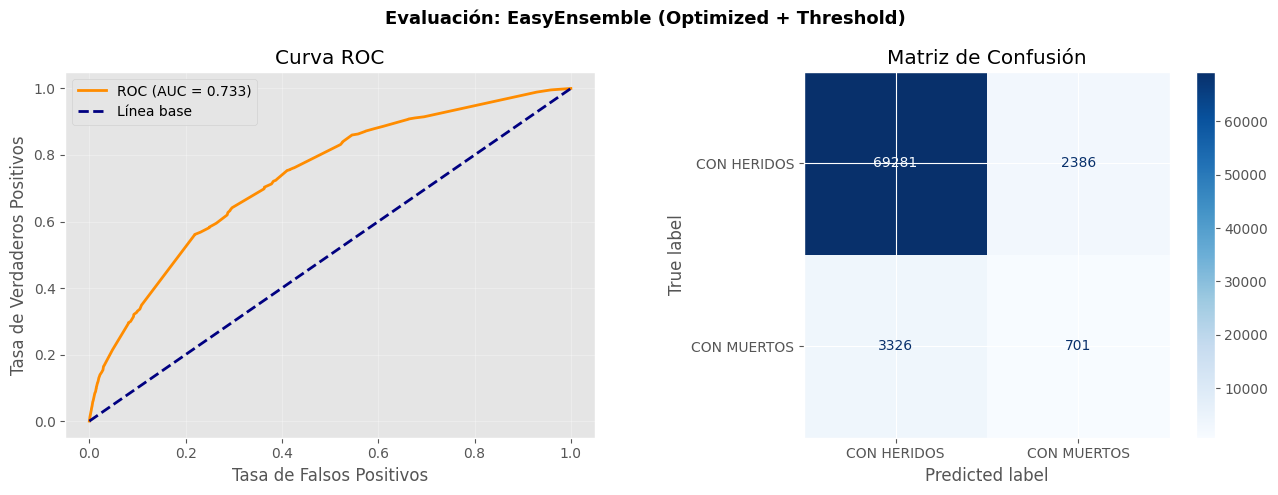

COMPARACIÓN BASE vs OPTIMIZADO
Métrica                         Base   Optimizado
--------------------------------------------------
F1-Macro                      0.4711       0.5787
F1-MUERTOS                    0.1721       0.1971
Recall-MUERTOS                0.7033       0.1741
Precision-MUERTOS             0.0980       0.2271

Mejora F1-Macro: +0.1077


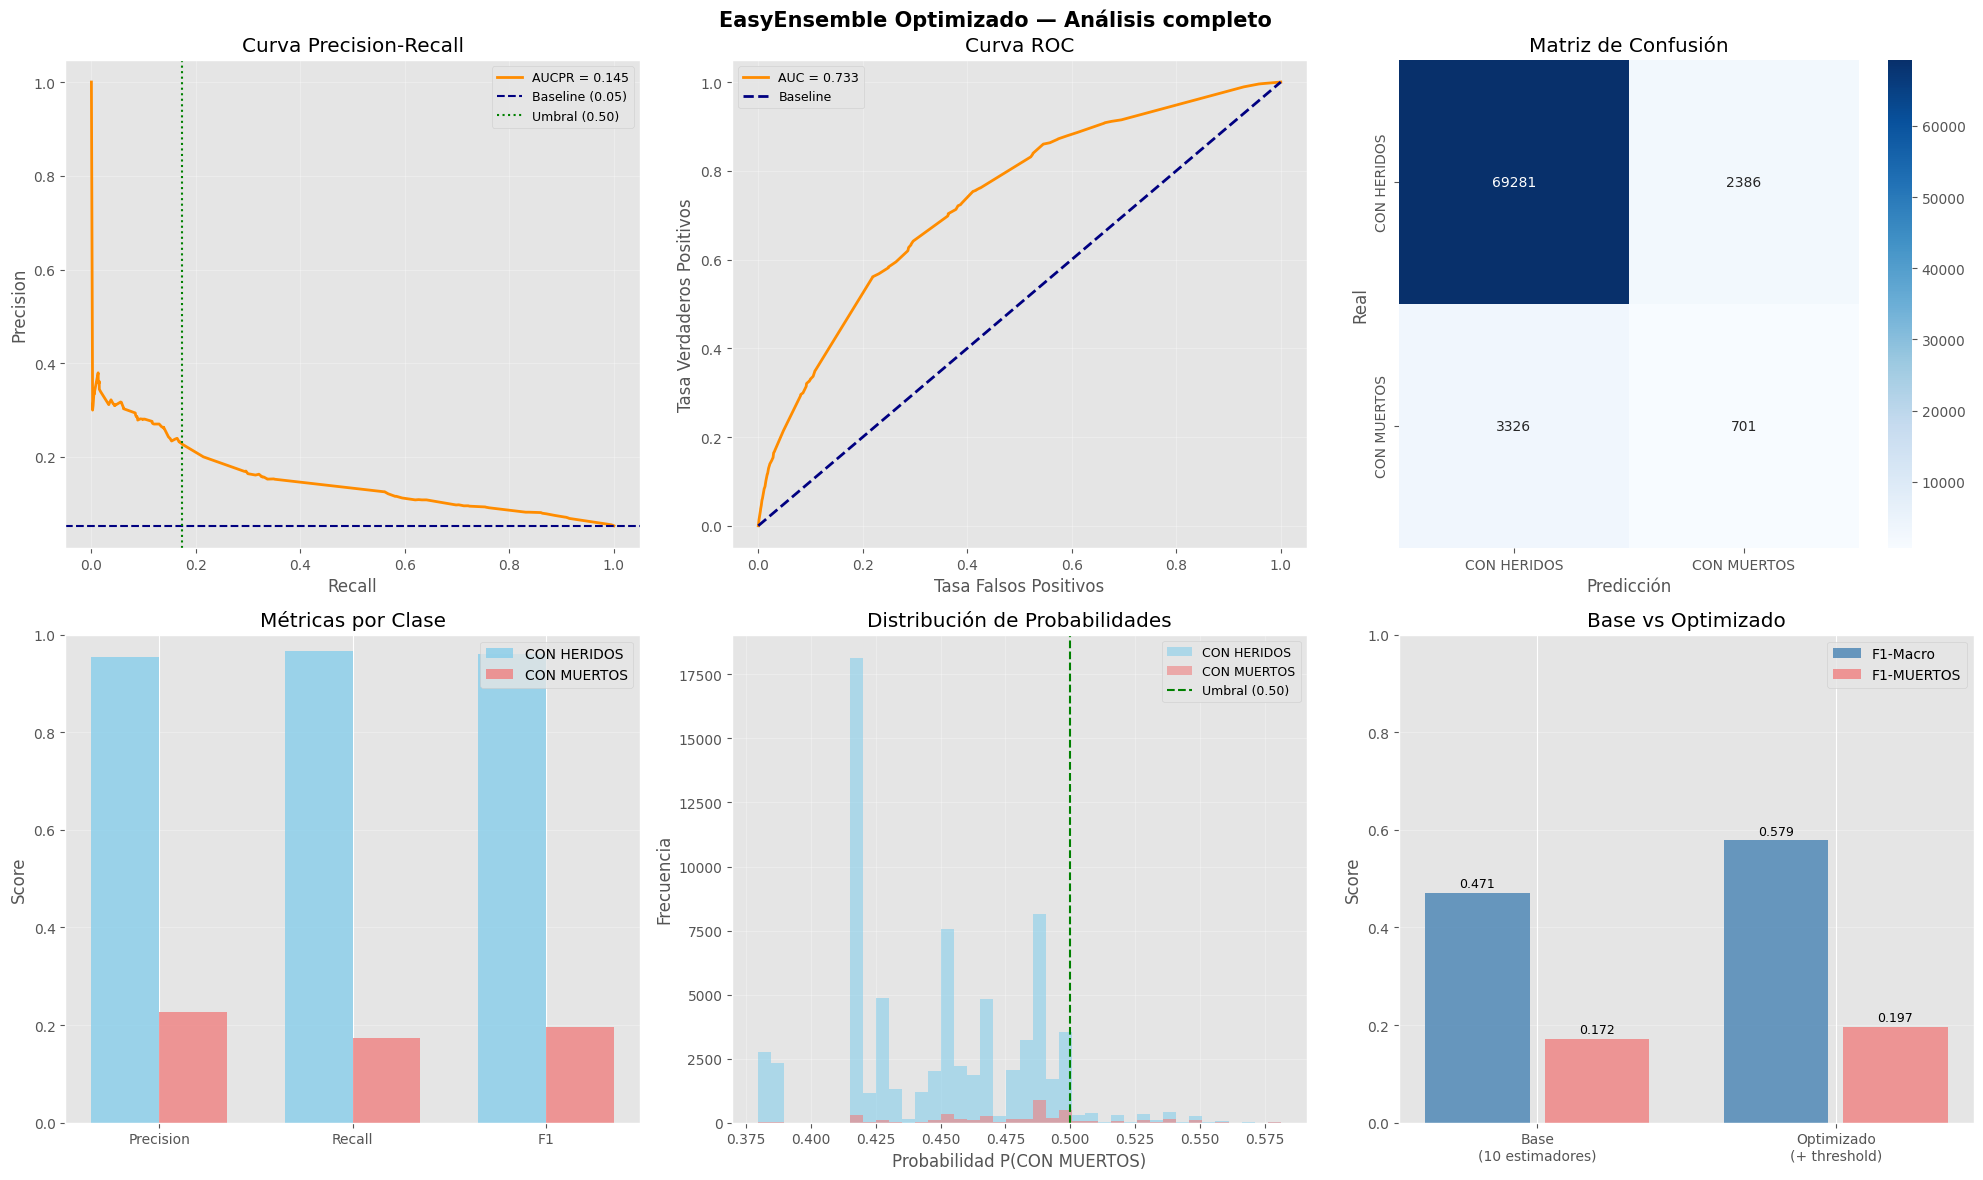


Interpretabilidad con LIME - EasyEnsemble

1. CASO CON MUERTOS correctamente clasificado


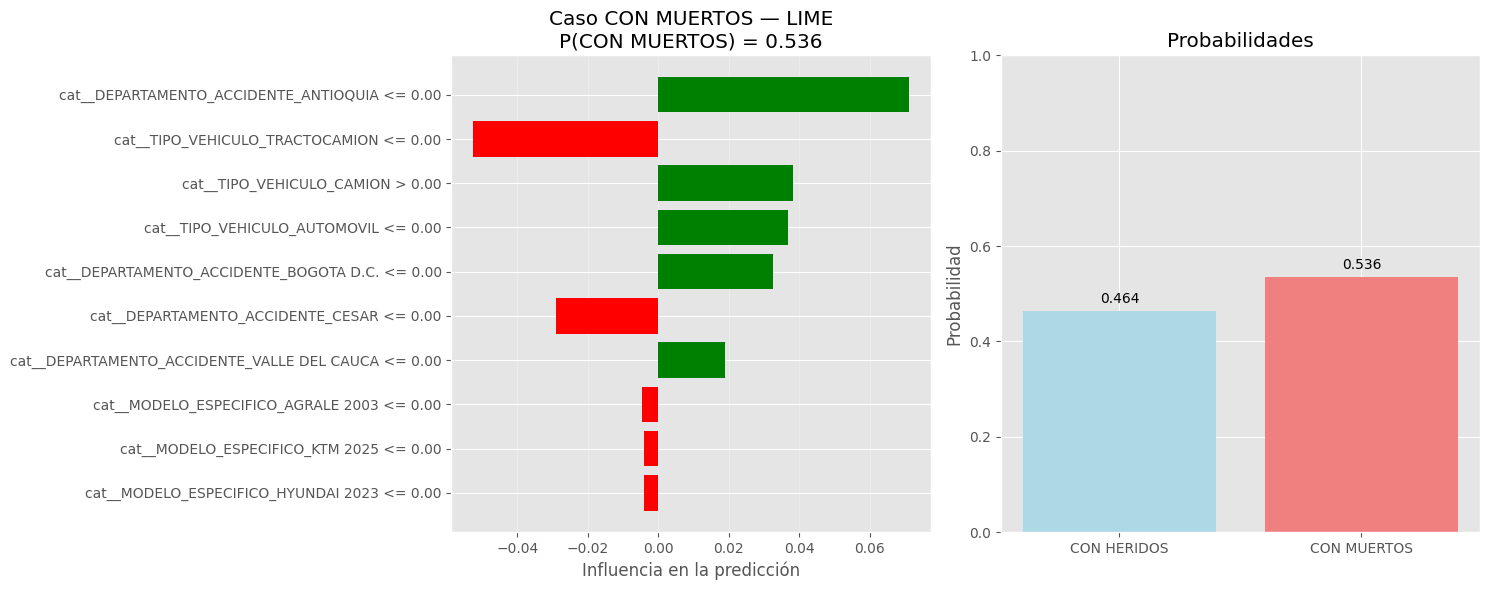


2. CASO CON HERIDOS correctamente clasificado


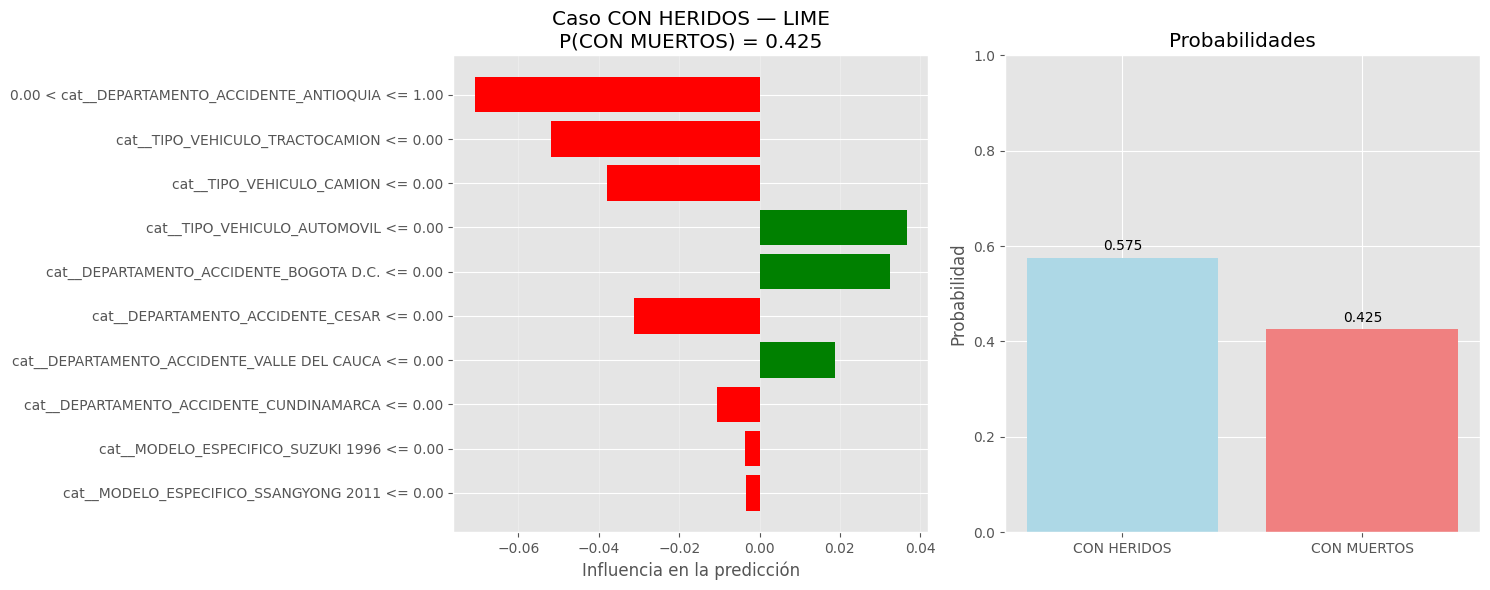

In [69]:
from imblearn.ensemble import EasyEnsembleClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    make_scorer, f1_score, average_precision_score,
    precision_recall_curve, precision_score, recall_score,
    classification_report, confusion_matrix
)
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, psutil

os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

# ── RATIO ─────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ── SUBMUESTRA 60% ────────────────────────────────────────────
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("="*60)
print("SUBMUESTRA PARA EasyEnsemble")
print("="*60)
print(f"Train completo:  {X_train.shape[0]:,} registros")
print(f"Submuestra:      {X_tr_sub.shape[0]:,} registros")
print(f"HERIDOS:         {(y_tr_sub==0).sum():,} ({(y_tr_sub==0).mean()*100:.1f}%)")
print(f"MUERTOS:         {(y_tr_sub==1).sum():,} ({(y_tr_sub==1).mean()*100:.1f}%)")

# ── SPLIT VALIDACIÓN para threshold tuning sin leakage ────────
X_tr_cv, X_val_thresh, y_tr_cv, y_val_thresh = train_test_split(
    X_tr_sub, y_tr_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_tr_sub
)
print(f"\nTrain CV:        {X_tr_cv.shape[0]:,}")
print(f"Val threshold:   {X_val_thresh.shape[0]:,}")

# ── PIPELINE BASE ─────────────────────────────────────────────
# EasyEnsemble ya maneja el desbalanceo internamente
# NO necesita SMOTE — usa undersampling de la mayoría por árbol
pipe_ee = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', EasyEnsembleClassifier(
        n_estimators=10,           # base para probar
        sampling_strategy='auto',  # balancea automáticamente
        replacement=False,
        random_state=RANDOM_STATE,
        n_jobs=-1                  # CPU paralelo — funciona
    ))
])

print("\n" + "="*60)
print("ENTRENANDO EasyEnsemble BASE...")
print("="*60)

import time
start = time.time()
pipe_ee.fit(X_tr_cv, y_tr_cv)
print(f"Tiempo base: {time.time()-start:.1f}s")

y_pred_base  = pipe_ee.predict(X_test)
y_proba_base = pipe_ee.predict_proba(X_test)[:, 1]

print("\nEasyEnsemble BASE — Resultados en Test:")
print(f"  F1-Macro:          {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"  F1-MUERTOS:        {f1_score(y_test, y_pred_base, pos_label=1):.4f}")
print(f"  Recall-MUERTOS:    {recall_score(y_test, y_pred_base, pos_label=1):.4f}")
print(f"  Precision-MUERTOS: {precision_score(y_test, y_pred_base, pos_label=1, zero_division=0):.4f}")

# ── PASO 1: RandomizedSearch ──────────────────────────────────
param_grid = {
    "model__n_estimators":      [10, 20, 30, 50],
    "model__sampling_strategy": ['auto', 0.5, 0.75, 1.0],
    "model__replacement":       [True, False],
}

print("\n[PASO 1] RandomizedSearch (15 iter, 3 folds)...")
print("Estimado: ~30-60 min\n")

random_search = RandomizedSearchCV(
    pipe_ee,
    param_grid,
    n_iter=15,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro'),   # F1-Macro como objetivo
    n_jobs=1,              # evita conflictos de serialización en Windows
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

start = time.time()
random_search.fit(X_tr_cv, y_tr_cv)
print(f"\nTiempo búsqueda: {(time.time()-start)/60:.1f} min")
print(f"Mejores parámetros: {random_search.best_params_}")
print(f"Mejor F1-Macro (CV): {random_search.best_score_:.4f}")

final_model = random_search.best_estimator_

# ── PASO 2: Threshold tuning sobre validación ─────────────────
print("\n[PASO 2] Threshold tuning sobre validación...")
y_proba_val = final_model.predict_proba(X_val_thresh)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)

precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1-Macro':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p  = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r  = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    fm = f1_score(y_val_thresh,        pred, average='macro')
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': fm, 'pred': pred}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {fm:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")

# ── EVALUACIÓN FINAL en X_test ────────────────────────────────
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)

aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)
f1_macro    = f1_score(y_test,        y_pred, average='macro')

print("\n" + "="*60)
print("RESULTADOS FINALES (EasyEnsemble)")
print("="*60)
print(f"F1-Macro:          {f1_macro:.4f}")
print(f"F1-MUERTOS:        {f1_1:.4f}")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

result = evaluate_model(
    final_model,
    X_tr_cv, X_test, y_tr_cv, y_test,
    model_name="EasyEnsemble (Optimized + Threshold)",
    cv_folds=3,
    make_plots=True,
    refit=False
)
results.append(result)

# ── COMPARACIÓN BASE vs OPTIMIZADO ────────────────────────────
print("="*60)
print("COMPARACIÓN BASE vs OPTIMIZADO")
print("="*60)

f1_macro_base = f1_score(y_test, y_pred_base, average='macro')
f1_macro_opt  = f1_score(y_test, y_pred,      average='macro')
f1_base_min   = f1_score(y_test, y_pred_base, pos_label=1)
f1_opt_min    = f1_score(y_test, y_pred,      pos_label=1)

print(f"{'Métrica':<25} {'Base':>10} {'Optimizado':>12}")
print("-" * 50)
print(f"{'F1-Macro':<25} {f1_macro_base:>10.4f} {f1_macro_opt:>12.4f}")
print(f"{'F1-MUERTOS':<25} {f1_base_min:>10.4f} {f1_opt_min:>12.4f}")
print(f"{'Recall-MUERTOS':<25} {recall_score(y_test, y_pred_base, pos_label=1):>10.4f} {recall_1:>12.4f}")
print(f"{'Precision-MUERTOS':<25} {precision_score(y_test, y_pred_base, pos_label=1, zero_division=0):>10.4f} {precision_1:>12.4f}")
print(f"\nMejora F1-Macro: {f1_macro_opt - f1_macro_base:+.4f}")

# ── GRÁFICAS ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('EasyEnsemble Optimizado — Análisis completo', fontsize=15, fontweight='bold')

# 1. Curva Precision-Recall
precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0, 0].plot(recalls_t, precisions_t, color='darkorange', lw=2, label=f'AUCPR = {aucpr:.3f}')
axes[0, 0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0, 0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0, 0].set_xlabel('Recall'); axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Curva Precision-Recall')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(alpha=0.3)

# 2. Curva ROC
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc_val      = roc_auc_score(y_test, y_proba_test)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_val:.3f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline')
axes[0, 1].set_xlabel('Tasa Falsos Positivos'); axes[0, 1].set_ylabel('Tasa Verdaderos Positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(alpha=0.3)

# 3. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2],
            xticklabels=class_names, yticklabels=class_names)
axes[0, 2].set_title('Matriz de Confusión')
axes[0, 2].set_xlabel('Predicción'); axes[0, 2].set_ylabel('Real')

# 4. Métricas por clase
x = np.arange(3); width = 0.35
axes[1, 0].bar(x - width/2, [precision_0, recall_0, f1_0], width,
               label=class_names[0], alpha=0.8, color='skyblue')
axes[1, 0].bar(x + width/2, [precision_1, recall_1, f1_1], width,
               label=class_names[1], alpha=0.8, color='lightcoral')
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[1, 0].set_ylabel('Score'); axes[1, 0].set_title('Métricas por Clase')
axes[1, 0].legend(); axes[1, 0].set_ylim(0, 1); axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Distribución de probabilidades
axes[1, 1].hist(y_proba_test[y_test == 0], bins=40, alpha=0.6,
                label=class_names[0], color='skyblue')
axes[1, 1].hist(y_proba_test[y_test == 1], bins=40, alpha=0.6,
                label=class_names[1], color='lightcoral')
axes[1, 1].axvline(x=best_thresh, color='green', linestyle='--',
                   label=f'Umbral ({best_thresh:.2f})')
axes[1, 1].set_xlabel('Probabilidad P(CON MUERTOS)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Probabilidades')
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(alpha=0.3)

# 6. Comparación Base vs Optimizado
modelos   = ['Base\n(10 estimadores)', 'Optimizado\n(+ threshold)']
f1_macros = [f1_macro_base, f1_macro_opt]
f1_mins   = [f1_base_min,   f1_opt_min]

x_comp = np.arange(len(modelos))
bars1  = axes[1, 2].bar(x_comp - 0.2, f1_macros, 0.35, label='F1-Macro',   color='steelblue',  alpha=0.8)
bars2  = axes[1, 2].bar(x_comp + 0.2, f1_mins,   0.35, label='F1-MUERTOS', color='lightcoral', alpha=0.8)
for bar in bars1 + bars2:
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
axes[1, 2].set_xticks(x_comp); axes[1, 2].set_xticklabels(modelos)
axes[1, 2].set_ylabel('Score'); axes[1, 2].set_title('Base vs Optimizado')
axes[1, 2].legend(); axes[1, 2].set_ylim(0, 1); axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── LIME ──────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - EasyEnsemble")

X_train_processed  = final_model.named_steps['preprocessor'].transform(X_tr_cv)
X_test_processed   = final_model.named_steps['preprocessor'].transform(X_test)
feature_names_lime = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    random_state=RANDOM_STATE
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)

def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]
    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features))); ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3); ax1.invert_yaxis()
    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad'); ax2.set_title('Probabilidades')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_1) > 0:
    i = idx_1[0]
    print(f"\n1. CASO {class_names[1]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_proba_test[i])

idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_0) > 0:
    i = idx_0[0]
    print(f"\n2. CASO {class_names[0]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_proba_test[i])

HERIDOS: 286,666 | MUERTOS: 16,110 | ratio: 17.79
SUBMUESTRA PARA Balanced Bagging + LightGBM
Train completo:  302,776 registros
Submuestra:      181,665 registros
HERIDOS:         171,999 (94.7%)
MUERTOS:         9,666 (5.3%)

Train CV:        145,332
Val threshold:   36,333

ENTRENANDO Balanced Bagging BASE...
Tiempo base: 26.7s

Balanced Bagging BASE — Resultados en Test:
  F1-Macro:          0.5247
  F1-MUERTOS:        0.2054
  Recall-MUERTOS:    0.6335
  Precision-MUERTOS: 0.1225

[PASO 1] RandomizedSearch (15 iter, 3 folds)...
Estimado: ~30-60 min

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Tiempo búsqueda: 50.6 min
Mejores parámetros:  {'model__sampling_strategy': 0.5, 'model__replacement': False, 'model__n_estimators': 50, 'model__estimator__subsample': 0.9, 'model__estimator__num_leaves': 31, 'model__estimator__max_depth': 3, 'model__estimator__learning_rate': 0.1, 'model__estimator__colsample_bytree': 0.9}
Mejor F1-Macro (CV): 0.5930

[PASO 2] Threshold tun

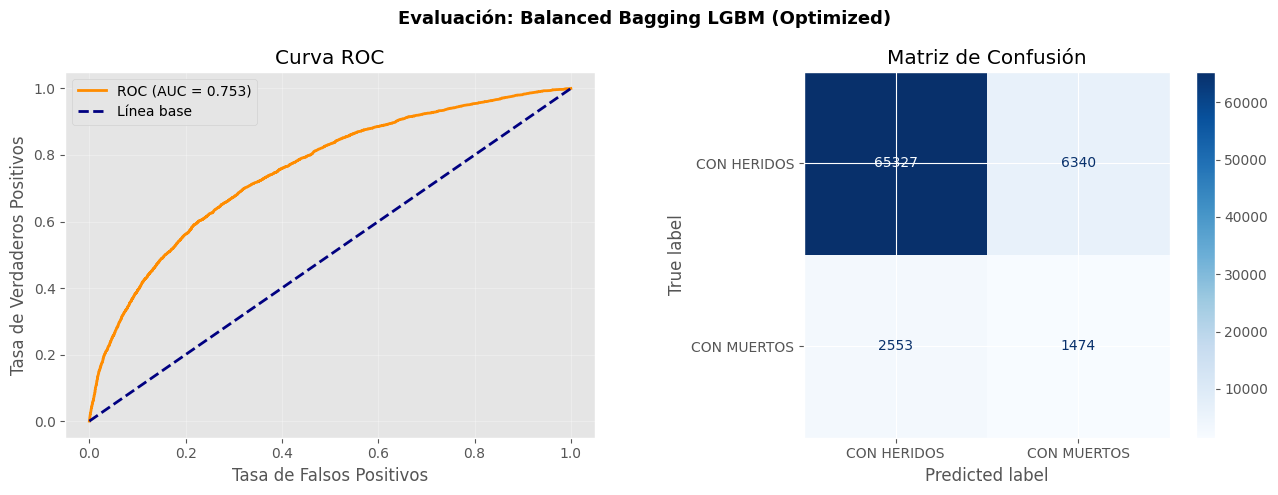

COMPARACIÓN BASE vs OPTIMIZADO
Métrica                         Base   Optimizado
--------------------------------------------------
F1-Macro                      0.5247       0.5961
F1-MUERTOS                    0.2054       0.2352
Recall-MUERTOS                0.6335       0.2349
Precision-MUERTOS             0.1225       0.2354

Mejora F1-Macro: +0.0714


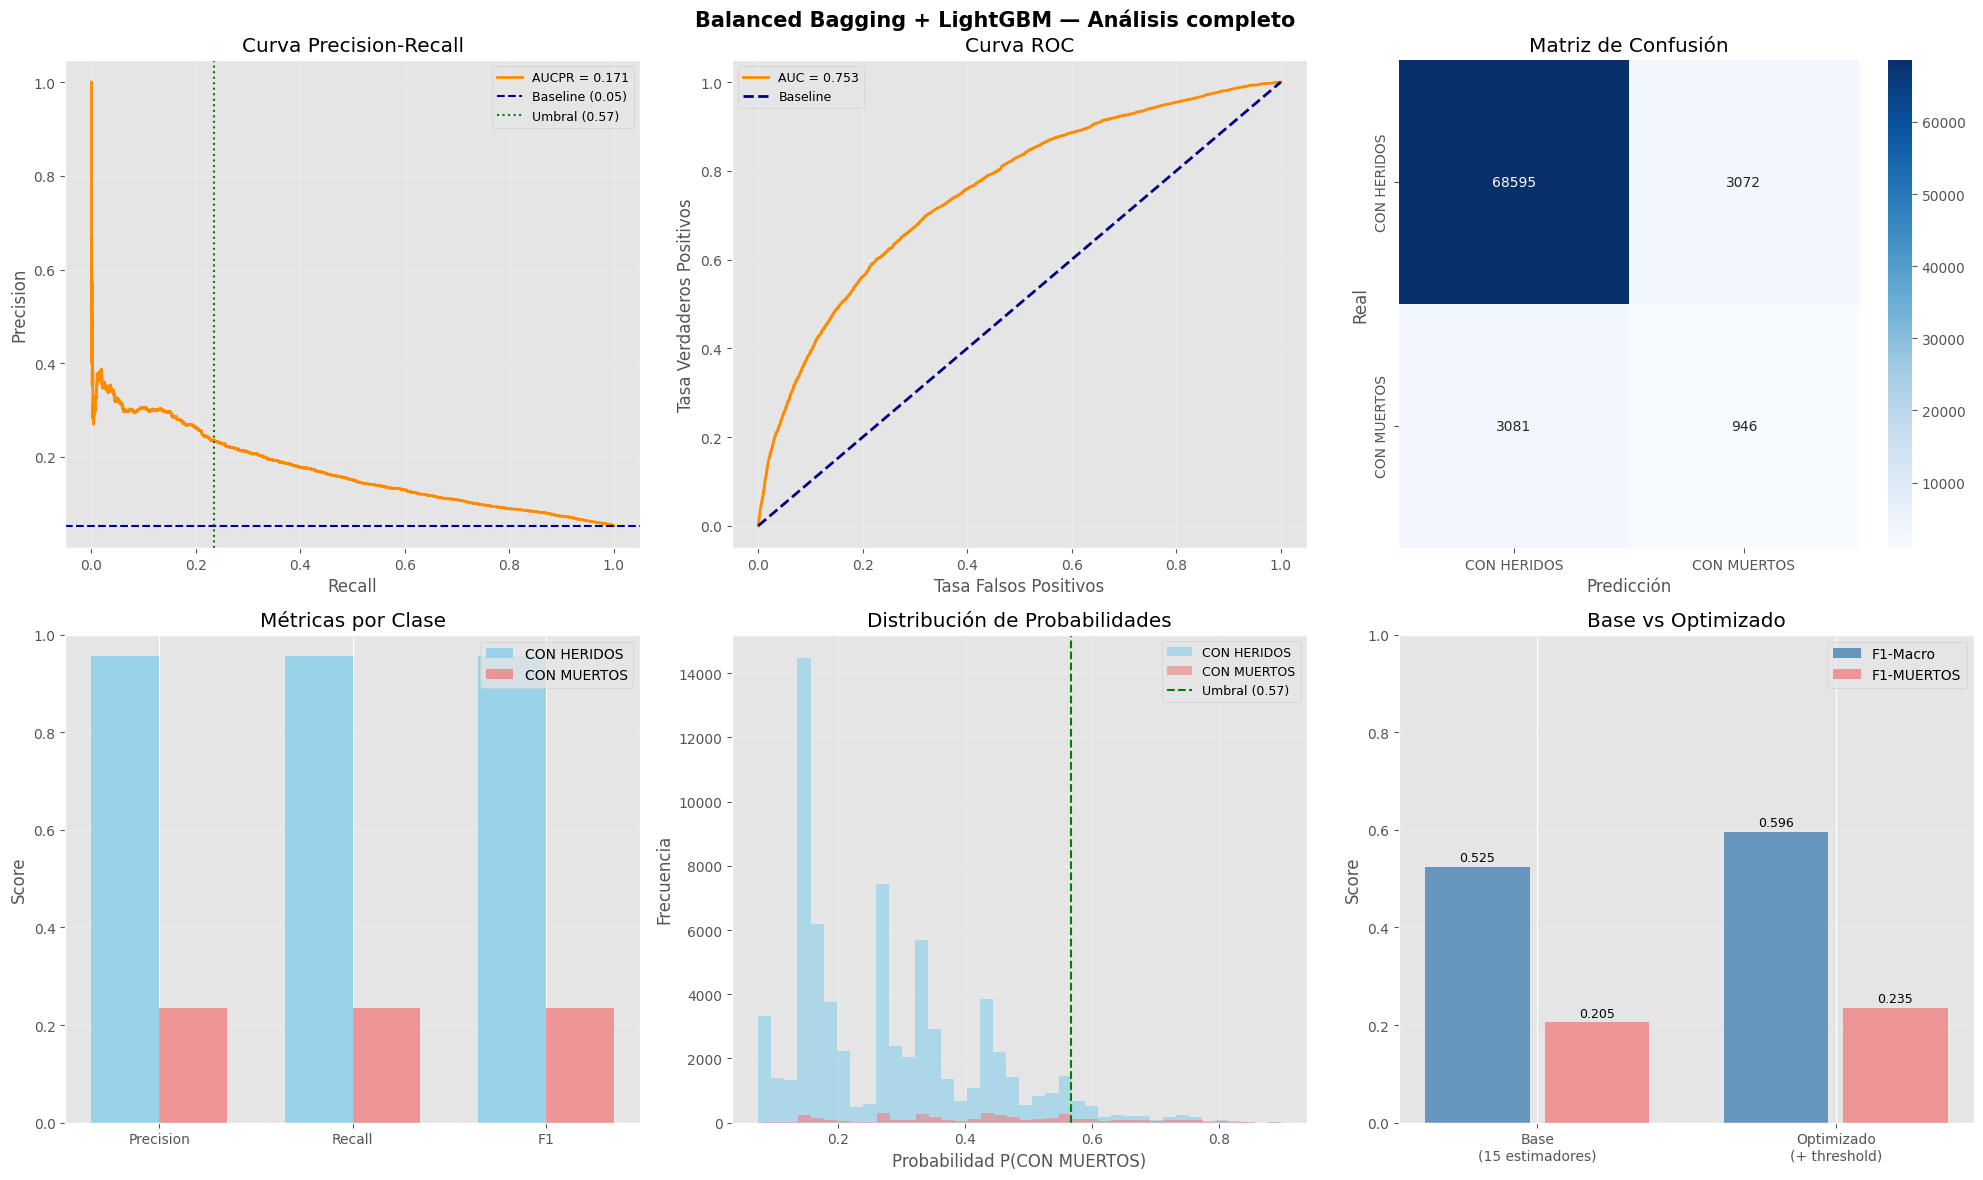


Interpretabilidad con LIME - Balanced Bagging + LightGBM

1. CASO CON MUERTOS correctamente clasificado


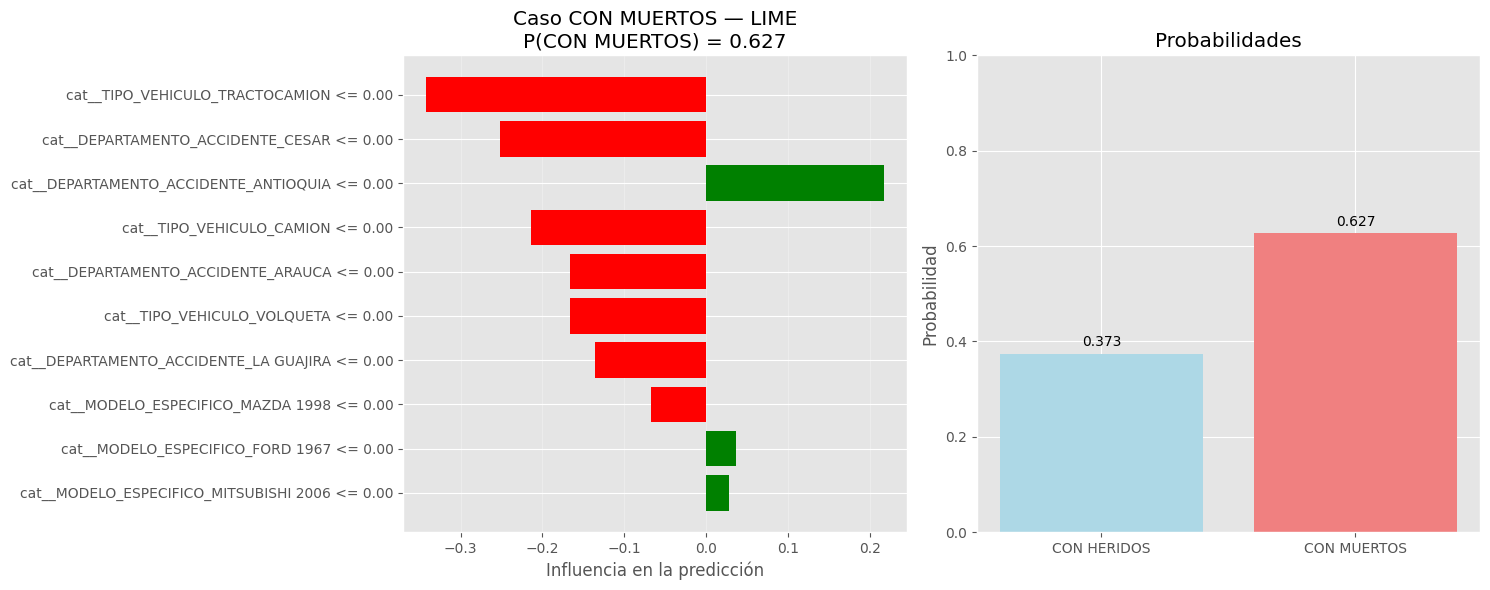


2. CASO CON HERIDOS correctamente clasificado


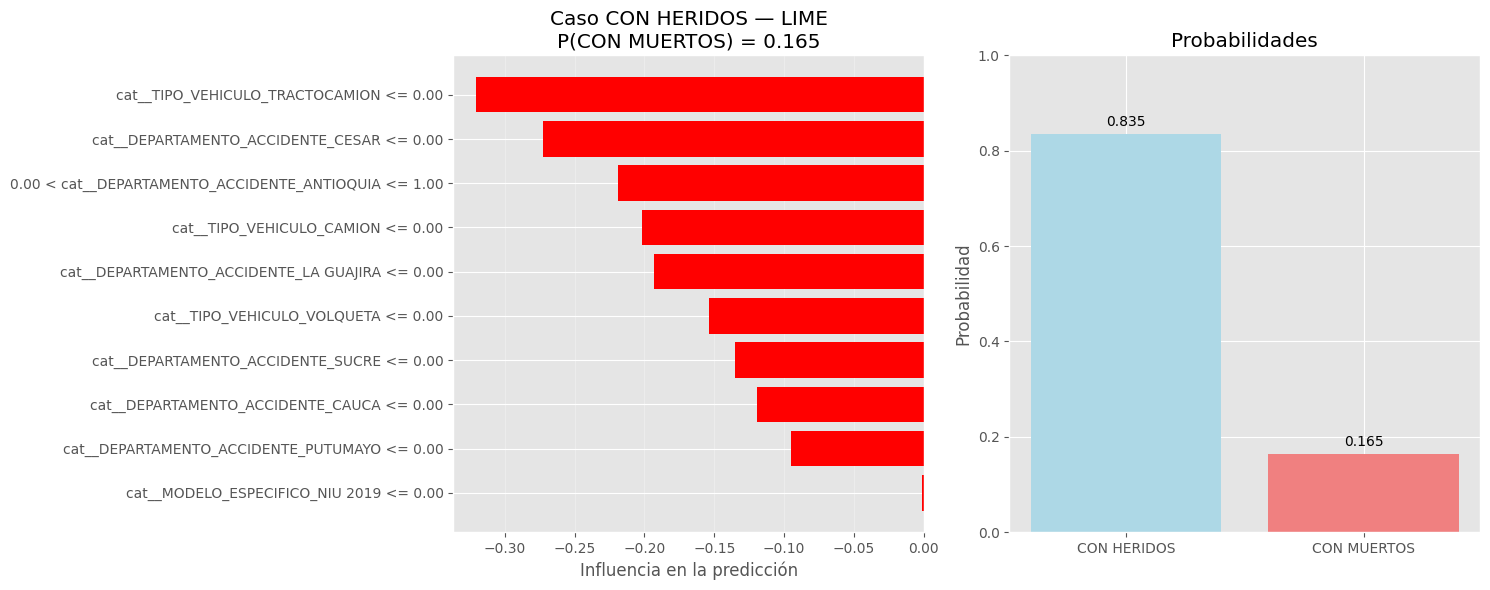

In [70]:
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    make_scorer, f1_score, average_precision_score,
    precision_recall_curve, precision_score, recall_score,
    classification_report, confusion_matrix
)
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os, psutil

os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

# ── RATIO ─────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"HERIDOS: {neg:,} | MUERTOS: {pos:,} | ratio: {ratio:.2f}")

# ── SUBMUESTRA 60% ────────────────────────────────────────────
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train, y_train,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("="*60)
print("SUBMUESTRA PARA Balanced Bagging + LightGBM")
print("="*60)
print(f"Train completo:  {X_train.shape[0]:,} registros")
print(f"Submuestra:      {X_tr_sub.shape[0]:,} registros")
print(f"HERIDOS:         {(y_tr_sub==0).sum():,} ({(y_tr_sub==0).mean()*100:.1f}%)")
print(f"MUERTOS:         {(y_tr_sub==1).sum():,} ({(y_tr_sub==1).mean()*100:.1f}%)")

# ── SPLIT VALIDACIÓN para threshold tuning sin leakage ────────
X_tr_cv, X_val_thresh, y_tr_cv, y_val_thresh = train_test_split(
    X_tr_sub, y_tr_sub,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_tr_sub
)
print(f"\nTrain CV:        {X_tr_cv.shape[0]:,}")
print(f"Val threshold:   {X_val_thresh.shape[0]:,}")

# ── PIPELINE BASE ─────────────────────────────────────────────
lgbm_base = lgb.LGBMClassifier(
    random_state=RANDOM_STATE,
    device='gpu',
    verbose=-1,
    n_jobs=1
)

pipe_bb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedBaggingClassifier(
        estimator=lgbm_base,
        n_estimators=15,
        sampling_strategy='auto',
        replacement=False,
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

print("\n" + "="*60)
print("ENTRENANDO Balanced Bagging BASE...")
print("="*60)

start = time.time()
pipe_bb.fit(X_tr_cv, y_tr_cv)
print(f"Tiempo base: {time.time()-start:.1f}s")

y_pred_base  = pipe_bb.predict(X_test)
y_proba_base = pipe_bb.predict_proba(X_test)[:, 1]

print("\nBalanced Bagging BASE — Resultados en Test:")
print(f"  F1-Macro:          {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"  F1-MUERTOS:        {f1_score(y_test, y_pred_base, pos_label=1):.4f}")
print(f"  Recall-MUERTOS:    {recall_score(y_test, y_pred_base, pos_label=1):.4f}")
print(f"  Precision-MUERTOS: {precision_score(y_test, y_pred_base, pos_label=1, zero_division=0):.4f}")

# ── PASO 1: RandomizedSearch ──────────────────────────────────
param_grid = {
    "model__n_estimators":               [15, 30, 50],
    "model__sampling_strategy":          ['auto', 0.5, 0.75],
    "model__replacement":                [True, False],
    "model__estimator__max_depth":       [3, 5, 7],
    "model__estimator__learning_rate":   [0.05, 0.1],
    "model__estimator__num_leaves":      [31, 63],
    "model__estimator__subsample":       [0.8, 0.9],
    "model__estimator__colsample_bytree":[0.8, 0.9],
}

print("\n[PASO 1] RandomizedSearch (15 iter, 3 folds)...")
print("Estimado: ~30-60 min\n")

random_search = RandomizedSearchCV(
    pipe_bb,
    param_grid,
    n_iter=15,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro'),
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)

start = time.time()
random_search.fit(X_tr_cv, y_tr_cv)
print(f"\nTiempo búsqueda: {(time.time()-start)/60:.1f} min")
print(f"Mejores parámetros:  {random_search.best_params_}")
print(f"Mejor F1-Macro (CV): {random_search.best_score_:.4f}")

final_model = random_search.best_estimator_

# ── PASO 2: Threshold tuning sobre validación ─────────────────
print("\n[PASO 2] Threshold tuning sobre validación...")
y_proba_val = final_model.predict_proba(X_val_thresh)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh, y_proba_val)

precisions_cut = precisions[:-1]
recalls_cut    = recalls[:-1]
f1s            = 2 * (precisions_cut * recalls_cut) / (precisions_cut + recalls_cut + 1e-9)

thresh_max_f1     = thresholds[np.argmax(f1s)]
mask              = precisions_cut >= 0.30
thresh_min_prec   = thresholds[mask][np.argmax(recalls_cut[mask])] if mask.any() else thresh_max_f1
thresh_equilibrio = thresholds[np.argmin(np.abs(precisions_cut - recalls_cut))]

print(f"\n{'Estrategia':<22} {'Precision':>10} {'Recall':>10} {'F1-Macro':>10}")
print("-" * 54)

resultados_thresh = {}
for nombre, thresh in [
    ("Default (0.5)",   0.5),
    ("Máx F1",          thresh_max_f1),
    ("Precision≥0.30",  thresh_min_prec),
    ("Equilibrio P=R",  thresh_equilibrio),
]:
    pred = (y_proba_val >= thresh).astype(int)
    p  = precision_score(y_val_thresh, pred, pos_label=1, zero_division=0)
    r  = recall_score(y_val_thresh,    pred, pos_label=1, zero_division=0)
    fm = f1_score(y_val_thresh,        pred, average='macro')
    resultados_thresh[nombre] = {'thresh': thresh, 'precision': p, 'recall': r, 'f1': fm, 'pred': pred}
    print(f"{nombre:<22} {p:>10.4f} {r:>10.4f} {fm:>10.4f}")

mejor_estrategia = max(resultados_thresh, key=lambda k: resultados_thresh[k]['f1'])
best_thresh      = resultados_thresh[mejor_estrategia]['thresh']
print(f"\nEstrategia seleccionada: '{mejor_estrategia}' (thresh={best_thresh:.3f})")

# ── EVALUACIÓN FINAL en X_test ────────────────────────────────
y_proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred       = (y_proba_test >= best_thresh).astype(int)

aucpr       = average_precision_score(y_test, y_proba_test)
precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test,    y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test,    y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test,        y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)
f1_macro    = f1_score(y_test,        y_pred, average='macro')

print("\n" + "="*60)
print("RESULTADOS FINALES (Balanced Bagging + LightGBM)")
print("="*60)
print(f"F1-Macro:          {f1_macro:.4f}")
print(f"F1-MUERTOS:        {f1_1:.4f}")
print(f"Recall-MUERTOS:    {recall_1:.4f}")
print(f"Precision-MUERTOS: {precision_1:.4f}")
print(f"AUCPR:             {aucpr:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

result = evaluate_model(
    final_model,
    X_tr_cv, X_test, y_tr_cv, y_test,
    model_name="Balanced Bagging LGBM (Optimized)",
    cv_folds=3,
    make_plots=True,
    refit=False
)
results.append(result)

# ── COMPARACIÓN BASE vs OPTIMIZADO ────────────────────────────
print("="*60)
print("COMPARACIÓN BASE vs OPTIMIZADO")
print("="*60)

f1_macro_base = f1_score(y_test, y_pred_base, average='macro')
f1_macro_opt  = f1_score(y_test, y_pred,      average='macro')
f1_base_min   = f1_score(y_test, y_pred_base, pos_label=1)
f1_opt_min    = f1_score(y_test, y_pred,      pos_label=1)

print(f"{'Métrica':<25} {'Base':>10} {'Optimizado':>12}")
print("-" * 50)
print(f"{'F1-Macro':<25} {f1_macro_base:>10.4f} {f1_macro_opt:>12.4f}")
print(f"{'F1-MUERTOS':<25} {f1_base_min:>10.4f} {f1_opt_min:>12.4f}")
print(f"{'Recall-MUERTOS':<25} {recall_score(y_test, y_pred_base, pos_label=1):>10.4f} {recall_1:>12.4f}")
print(f"{'Precision-MUERTOS':<25} {precision_score(y_test, y_pred_base, pos_label=1, zero_division=0):>10.4f} {precision_1:>12.4f}")
print(f"\nMejora F1-Macro: {f1_macro_opt - f1_macro_base:+.4f}")

# ── GRÁFICAS ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Balanced Bagging + LightGBM — Análisis completo', fontsize=15, fontweight='bold')

# 1. Curva Precision-Recall
precisions_t, recalls_t, _ = precision_recall_curve(y_test, y_proba_test)
axes[0, 0].plot(recalls_t, precisions_t, color='darkorange', lw=2, label=f'AUCPR = {aucpr:.3f}')
axes[0, 0].axhline(y=pos/(neg+pos), color='navy', linestyle='--', label=f'Baseline ({pos/(neg+pos):.2f})')
axes[0, 0].axvline(x=recall_1, color='green', linestyle=':', label=f'Umbral ({best_thresh:.2f})')
axes[0, 0].set_xlabel('Recall'); axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Curva Precision-Recall')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(alpha=0.3)

# 2. Curva ROC
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc_val      = roc_auc_score(y_test, y_proba_test)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_val:.3f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline')
axes[0, 1].set_xlabel('Tasa Falsos Positivos'); axes[0, 1].set_ylabel('Tasa Verdaderos Positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(alpha=0.3)

# 3. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2],
            xticklabels=class_names, yticklabels=class_names)
axes[0, 2].set_title('Matriz de Confusión')
axes[0, 2].set_xlabel('Predicción'); axes[0, 2].set_ylabel('Real')

# 4. Métricas por clase
x = np.arange(3); width = 0.35
axes[1, 0].bar(x - width/2, [precision_0, recall_0, f1_0], width,
               label=class_names[0], alpha=0.8, color='skyblue')
axes[1, 0].bar(x + width/2, [precision_1, recall_1, f1_1], width,
               label=class_names[1], alpha=0.8, color='lightcoral')
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(['Precision', 'Recall', 'F1'])
axes[1, 0].set_ylabel('Score'); axes[1, 0].set_title('Métricas por Clase')
axes[1, 0].legend(); axes[1, 0].set_ylim(0, 1); axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Distribución de probabilidades
axes[1, 1].hist(y_proba_test[y_test == 0], bins=40, alpha=0.6,
                label=class_names[0], color='skyblue')
axes[1, 1].hist(y_proba_test[y_test == 1], bins=40, alpha=0.6,
                label=class_names[1], color='lightcoral')
axes[1, 1].axvline(x=best_thresh, color='green', linestyle='--',
                   label=f'Umbral ({best_thresh:.2f})')
axes[1, 1].set_xlabel('Probabilidad P(CON MUERTOS)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Probabilidades')
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(alpha=0.3)

# 6. Comparación Base vs Optimizado
modelos   = ['Base\n(15 estimadores)', 'Optimizado\n(+ threshold)']
f1_macros = [f1_macro_base, f1_macro_opt]
f1_mins   = [f1_base_min,   f1_opt_min]

x_comp = np.arange(len(modelos))
bars1  = axes[1, 2].bar(x_comp - 0.2, f1_macros, 0.35, label='F1-Macro',   color='steelblue',  alpha=0.8)
bars2  = axes[1, 2].bar(x_comp + 0.2, f1_mins,   0.35, label='F1-MUERTOS', color='lightcoral', alpha=0.8)
for bar in bars1 + bars2:
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
axes[1, 2].set_xticks(x_comp); axes[1, 2].set_xticklabels(modelos)
axes[1, 2].set_ylabel('Score'); axes[1, 2].set_title('Base vs Optimizado')
axes[1, 2].legend(); axes[1, 2].set_ylim(0, 1); axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── LIME ──────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - Balanced Bagging + LightGBM")

X_train_processed  = final_model.named_steps['preprocessor'].transform(X_tr_cv)
X_test_processed   = final_model.named_steps['preprocessor'].transform(X_test)
feature_names_lime = final_model.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=class_names,
    mode='classification',
    random_state=RANDOM_STATE
)

# BalancedBaggingClassifier en inferencia no hace resampling
# predict_proba promedia directamente los estimadores base
predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)

def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]
    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features))); ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP({class_names[1]}) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3); ax1.invert_yaxis()
    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad'); ax2.set_title('Probabilidades')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_1) > 0:
    i = idx_1[0]
    print(f"\n1. CASO {class_names[1]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_proba_test[i])

idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_0) > 0:
    i = idx_0[0]
    print(f"\n2. CASO {class_names[0]} correctamente clasificado")
    exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
    plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_proba_test[i])